In [ ]:
#ドライブにアクセス
from google.colab import drive
drive.mount('/content/drive')
#ライブラリをインストール
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd
!pip install japanize-matplotlib
import japanize_matplotlib
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression, Lasso, LogisticRegression
from sklearn.decomposition import PCA, FactorAnalysis, KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc, pairwise_distances
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from sklearn.cross_decomposition import CCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.mixture import GaussianMixture
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.formula.api import ols
import stat
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
!pip install factor_analyzer japanize-matplotlib
from factor_analyzer import FactorAnalyzer
#データの読み込み
main_path = '/content/drive/MyDrive/data/poke_data/processed_poke_data_USUM.csv'
df = pd.read_csv(main_path)
#数値のみのデータフレーム
target_cols = ['HP', '攻撃', '防御', '特攻', '特防', '素早', '合計種族値', '高さ', '重さ','捕獲率','経験値','初期なつき度','雄率']
dfn= df[target_cols]

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 34.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=d54e298677fe8ea79676dbc246c5e9ab7ee4d87a200afa580044d59e698e687e
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=deac3fe462b7955e7ef4bc617d9d4c388495e8912f76f8b26163170a9526a989
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
#データの概要
print(df.head())
print(df.info())
print(df.describe())

       №       名前            英語名  HP   攻撃   防御   特攻   特防  素早  合計種族値  ...  \
0      1    フシギダネ      Bulbasaur  45   49   49   65   65  45    318  ...   
1      2    フシギソウ        Ivysaur  60   62   63   80   80  60    405  ...   
2      3    フシギバナ       Venusaur  80   82   83  100  100  80    525  ...   
3  003-1  メガフシギバナ  Mega Venusaur  80  100  123  122  120  80    625  ...   
4      4     ヒトカゲ     Charmander  39   52   43   60   50  65    309  ...   

      重さ 捕獲率   性別  経験値  初期なつき度         努力値       タマゴ    孵化    成長     雄率  
0    6.9  45  7:1   64      70        特攻+1    怪獣\n植物  5355  106万  0.875  
1   13.0  45  7:1  142      70  特攻+1\n特防+1    怪獣\n植物  5355  106万  0.875  
2  100.0  45  7:1  236      70  特攻+2\n特防+1    怪獣\n植物  5355  106万  0.875  
3  155.5  45  7:1  281      70  特攻+2\n特防+1    怪獣\n植物  5355  106万  0.875  
4    8.5  45  7:1   62      70        素早+1  怪獣\nドラゴン  5355  106万  0.875  

[5 rows x 24 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data

In [ ]:
#13章ノンパラメトリック法
#順位和検定
#変数
group_a_name = 'ほのお'
group_b_name = 'みず'
target_col_wls = '合計種族値'
data_a = dfn[df['タイプ1'] == group_a_name][target_col_wls]
data_b = dfn[df['タイプ1'] == group_b_name][target_col_wls]
print(f"【{group_a_name}】 サンプルサイズ: {len(data_a)}")
print(f"【{group_b_name}】 サンプルサイズ: {len(data_b)}")
#検定
u_stat, p_value_mw = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
print("\n" + "="*40)
print("ウィルコクソンの順位和検定 (Mann-Whitney U Test)")
print("="*40)
print(f"U統計量: {u_stat}")
print(f"P値      : {p_value_mw:.5f}")

if p_value_mw < 0.05:
    print("判定      : 有意水準5%で有意差あり（帰無仮説を棄却）")
else:
    print("判定      : 有意差なし（帰無仮説を棄却できない）")

【ほのお】 サンプルサイズ: 59
【みず】 サンプルサイズ: 123

ウィルコクソンの順位和検定 (Mann-Whitney U Test)
U統計量: 4139.5
P値      : 0.12481
判定      : 有意差なし（帰無仮説を棄却できない）


In [ ]:
#並び替え検定
#変数
group_c_name = 'むし'
group_d_name = 'ドラゴン'
target_col_rot = '合計種族値'
data_c = dfn[(df['タイプ1'] == group_c_name) | (df['タイプ2'] == group_c_name)][target_col_rot]
data_d = dfn[(df['タイプ1'] == group_d_name) | (df['タイプ2'] == group_d_name)][target_col_rot]
print(f"【{group_c_name}】 サンプルサイズ: {len(data_c)}")
print(f"【{group_d_name}】 サンプルサイズ: {len(data_d)}")
#試行
obs_diff = np.mean(data_c) - np.mean(data_d)
print(f"観測された平均値の差 ({group_c_name} - {group_d_name}): {obs_diff:.3f}")
pooled_data = np.concatenate([data_c, data_d])
n_c = len(data_c)
n_permutations = 10000 # 試行回数
count_extreme = 0
np.random.seed(42) # 再現性のためシード固定
for _ in range(n_permutations):
    # データをシャッフル
    np.random.shuffle(pooled_data)
    # 疑似的にグループAとBに分割
    perm_c = pooled_data[:n_c]
    perm_d = pooled_data[n_c:]

    # 差を計算
    perm_diff = np.mean(perm_c) - np.mean(perm_d)

    # 両側検定: 絶対値で比較
    if abs(perm_diff) >= abs(obs_diff):
        count_extreme += 1
#検定
p_value_perm = (count_extreme + 1) / (n_permutations + 1)
print(f"P値 (シミュレーション): {p_value_perm:.5f}")

if p_value_perm < 0.05:
    print("判定      : 有意水準5%で有意差あり")
else:
    print("判定      : 有意差なし")

【むし】 サンプルサイズ: 82
【ドラゴン】 サンプルサイズ: 61
観測された平均値の差 (むし - ドラゴン): -155.268
P値 (シミュレーション): 0.00010
判定      : 有意水準5%で有意差あり


In [ ]:
#符合検定
#ポケモン全体が攻撃よりか特攻よりか
#データ加工
vec_a = df['攻撃']
vec_b = df['特攻']
diff = vec_a - vec_b
positives = np.sum(diff > 0) # 攻撃 > 特攻
negatives = np.sum(diff < 0) # 攻撃 < 特攻
ties = np.sum(diff == 0)
n_valid = positives + negatives
res_sign = stats.binomtest(k=positives, n=n_valid, p=0.5, alternative='two-sided')
p_val_sign = res_sign.pvalue
print(f"攻撃が高い個体数 : {positives}")
print(f"特攻が高い個体数 : {negatives}")
print(f"同値 (除外)      : {ties}")
print(f"P値              : {p_val_sign:.6f}")

if p_val_sign < 0.05:
    print("判定: 有意差あり (攻撃と特攻の大小バランスは等しくない)")
else:
    print("判定: 有意差なし")

攻撃が高い個体数 : 450
特攻が高い個体数 : 326
同値 (除外)      : 144
P値              : 0.000010
判定: 有意差あり (攻撃と特攻の大小バランスは等しくない)


In [ ]:
#符号付順位和検定
#ポケモン全体が攻撃よりか特攻よりか
#データ加工
vec_a = df['攻撃']
vec_b = df['特攻']
diff = vec_a - vec_b
positives = np.sum(diff > 0) # 攻撃 > 特攻
negatives = np.sum(diff < 0) # 攻撃 < 特攻
ties = np.sum(diff == 0)
n_valid = positives + negatives
print(f"攻撃が高い個体数 : {positives}")
print(f"特攻が高い個体数 : {negatives}")
print(f"同値 (除外)      : {ties}")
w_stat, p_val_wilcoxon = stats.wilcoxon(vec_a, vec_b, alternative='two-sided')
print(f"検定統計量 (W)   : {w_stat}")
print(f"P値              : {p_val_wilcoxon:.8f}")
if p_val_wilcoxon < 0.05:
    print("判定: 有意差あり (攻撃と特攻の分布位置はずれている)")
else:
    print("判定: 有意差なし")


攻撃が高い個体数 : 450
特攻が高い個体数 : 326
同値 (除外)      : 144
検定統計量 (W)   : 117033.5
P値              : 0.00000007
判定: 有意差あり (攻撃と特攻の分布位置はずれている)


In [ ]:
#クラスカルウォリス検定
#草、炎、水タイプの分布に偏りがあるか
#データ加工
target_types_cwt = ['くさ', 'ほのお', 'みず']
target_col_cwt = '合計種族値'
groups = {}
for t in target_types_cwt:
    groups[t] = df[df['タイプ1'] == t][target_col_cwt] | df[df['タイプ2'] == t][target_col_cwt]
    print(f"【{t}】 サンプルサイズ: {len(groups[t])}, 中央値: {groups[t].median()}")
#検定
h_stat, p_value = stats.kruskal(*groups.values())
print(f"H統計量 : {h_stat:.4f}")
print(f"P値     : {p_value:.4f}")

if p_value < 0.05:
    print("判定    : 有意差あり（少なくとも1つのタイプは他と分布が異なる）")
else:
    print("判定    : 有意差なし（タイプ間に明確な強さの違いは見られない）")

【くさ】 サンプルサイズ: 109, 中央値: 1.0
【ほのお】 サンプルサイズ: 73, 中央値: 1.0
【みず】 サンプルサイズ: 141, 中央値: 1.0
H統計量 : 5.2089
P値     : 0.0739
判定    : 有意差なし（タイプ間に明確な強さの違いは見られない）


/tmp/ipython-input-3064678081.py:8: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  groups[t] = df[df['タイプ1'] == t][target_col_cwt] | df[df['タイプ2'] == t][target_col_cwt]
/tmp/ipython-input-3064678081.py:8: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  groups[t] = df[df['タイプ1'] == t][target_col_cwt] | df[df['タイプ2'] == t][target_col_cwt]
/tmp/ipython-input-3064678081.py:8: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  groups[t] = df[df['タイプ1'] == t][target_col_cwt] | df[df['タイプ2'] == t][target_col_cwt]


In [ ]:
#様々な相関係数
data_corr = df[['高さ', '重さ']]
r_pearson = data_corr['高さ'].corr(data_corr['重さ'], method='pearson')
r_spearman = data_corr['高さ'].corr(data_corr['重さ'], method='spearman')
r_kendall = data_corr['高さ'].corr(data_corr['重さ'], method='kendall')
print(f"ピアソン相関係数: {r_pearson:.4f}")
print(f"スピアマン順位相関係数: {r_spearman:.4f}")
print(f"ケンドール順位相関係数: {r_kendall:.4f}")

ピアソン相関係数: 0.6573
スピアマン順位相関係数: 0.8447
ケンドール順位相関係数: 0.6939


<>:69: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3277894573.py:69: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')


                            OLS Regression Results                            
Dep. Variable:                     重さ   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     698.4
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          6.60e-115
Time:                        08:01:18   Log-Likelihood:                -5484.5
No. Observations:                 920   AIC:                         1.097e+04
Df Residuals:                     918   BIC:                         1.098e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6319      4.327     -2.457      0.0

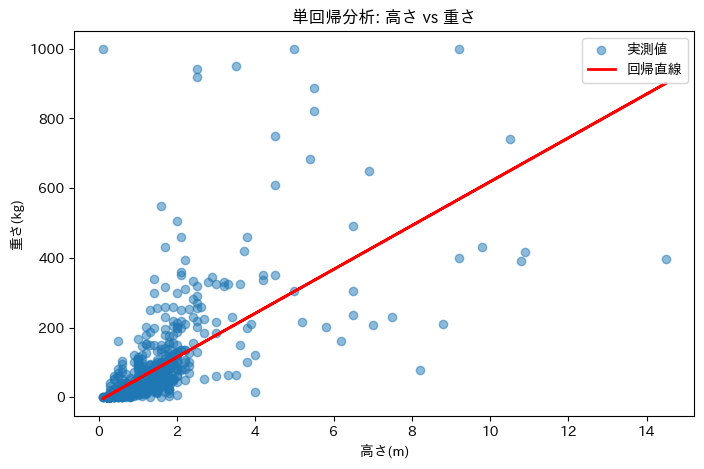

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


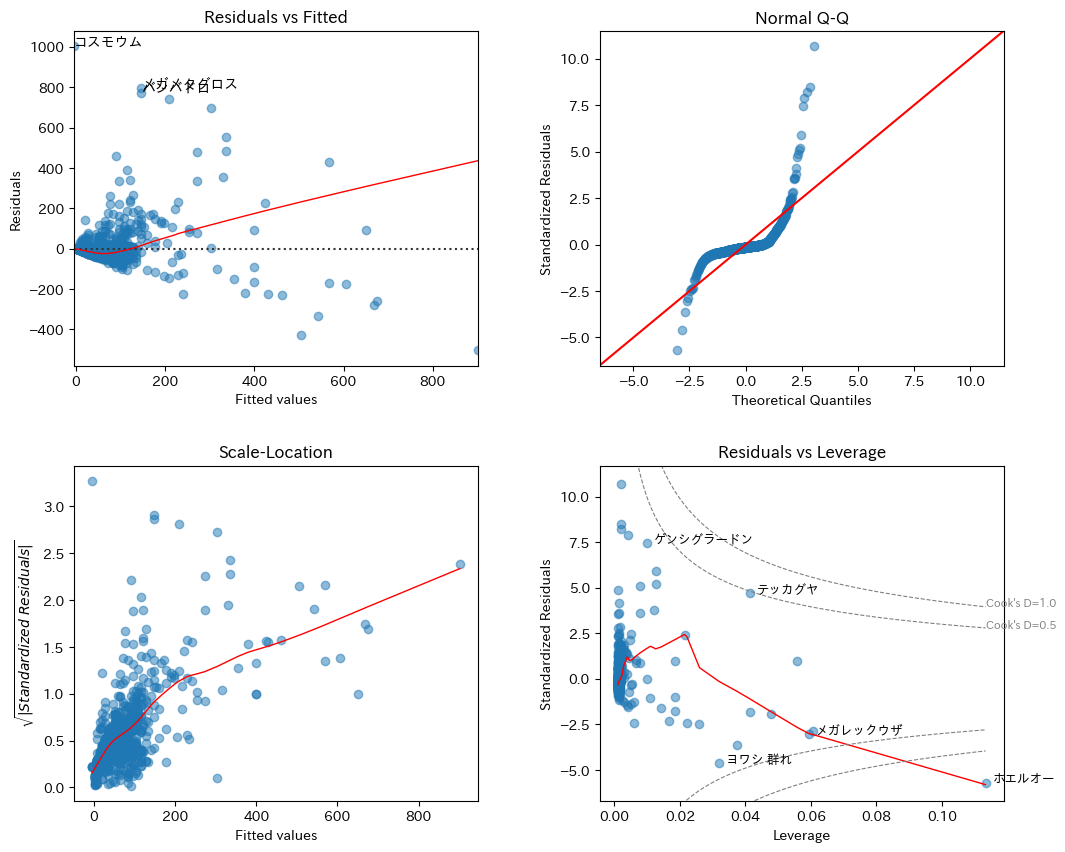

In [ ]:
#16,17章重回帰分析,回帰診断
#単回帰分析
#重さを目的変数に高さを説明変数に。つまりでかいポケモンは重い。
data_slr = df[['高さ', '重さ']]
y_slr = data_slr['重さ']
X_slr = data_slr['高さ']
X_slr_const = sm.add_constant(X_slr)
model_slr = sm.OLS(y_slr, X_slr_const).fit()
print(model_slr.summary())
#可視化
plt.figure(figsize=(8, 5))
plt.scatter(data_slr['高さ'], data_slr['重さ'], alpha=0.5, label='実測値')
plt.plot(data_slr['高さ'], model_slr.predict(X_slr_const), color='red', linewidth=2, label='回帰直線')
plt.xlabel('高さ(m)')
plt.ylabel('重さ(kg)')
plt.title('単回帰分析: 高さ vs 重さ')
plt.legend()
plt.show()
#診断
names = df['名前']
def plot_lm_diagnostics_enhanced(model, labels=None):
    # 統計量の取得
    fitted = model.fittedvalues
    residuals = model.resid
    norm_residuals = model.get_influence().resid_studentized_internal
    norm_residuals_abs_sqrt = np.sqrt(np.abs(norm_residuals))
    leverage = model.get_influence().hat_matrix_diag
    cooks = model.get_influence().cooks_distance[0]

    # プロット枠の作成
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # --- 共通処理: 上位の外れ値にラベルを貼る関数 ---
    def annotate_outliers(x, y, ax, n=3):
        if labels is None: return
        # Cookの距離が大きい順にn個選ぶ
        top_indices = np.argsort(cooks)[-n:]
        for i in top_indices:
            ax.annotate(labels.iloc[i],
                        xy=(x[i], y[i]),
                        xytext=(5, 0), textcoords='offset points',
                        color='black', fontsize=9)

    # 1. Residuals vs Fitted
    sns.residplot(x=fitted, y=residuals, lowess=True,
                  scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1}, ax=axes[0, 0])
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')
    # 残差の絶対値が大きい順にラベル表示
    top_resid = np.argsort(np.abs(residuals))[-3:]
    for i in top_resid:
        axes[0, 0].annotate(labels.iloc[i], xy=(fitted[i], residuals[i]))

    # 2. Normal Q-Q
    QQ = ProbPlot(norm_residuals)
    QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1, ax=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')
    axes[0, 1].set_xlabel('Theoretical Quantiles')
    axes[0, 1].set_ylabel('Standardized Residuals')

    # 3. Scale-Location
    axes[1, 0].scatter(fitted, norm_residuals_abs_sqrt, alpha=0.5)
    sns.regplot(x=fitted, y=norm_residuals_abs_sqrt, scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1}, ax=axes[1, 0])
    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')

    # 4. Residuals vs Leverage (Cook's Distance Contours 追加)
    axes[1, 1].scatter(leverage, norm_residuals, alpha=0.5)
    sns.regplot(x=leverage, y=norm_residuals, scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1}, ax=axes[1, 1])

    # --- Cookの距離の等高線を描画 ---
    p = len(model.params) # パラメータ数
    x_pos = np.linspace(min(leverage)+0.001, max(leverage), 100)

    # 等高線の数式: Standardized Residuals = sqrt(CookD * p * (1-h)/h)
    def r_cooks(D, x, p):
        return np.sqrt(D * p * (1 - x) / x)

    # 0.5 と 1.0 のラインを描画
    for D in [0.5, 1.0]:
        y_pos = r_cooks(D, x_pos, p)
        axes[1, 1].plot(x_pos, y_pos, linestyle='--', color='gray', linewidth=0.8)      # 上側
        axes[1, 1].plot(x_pos, -y_pos, linestyle='--', color='gray', linewidth=0.8)     # 下側
        # 端っこにテキスト表示
        if not np.isnan(y_pos[-1]):
             axes[1, 1].text(x_pos[-1], y_pos[-1], f'Cook\'s D={D}', fontsize=8, color='gray')

    axes[1, 1].set_title('Residuals vs Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Standardized Residuals')
    axes[1, 1].set_ylim(min(norm_residuals)-1, max(norm_residuals)+1)

    # 外れ値（影響力が大きい点）のラベル表示
    annotate_outliers(leverage, norm_residuals, axes[1, 1], n=5)

    plt.show()

plot_lm_diagnostics_enhanced(model_slr, names)


<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:71: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-169436400.py:71: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')
/tmp/ipython-input-169436400.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_log['log_height'] = np.log(data_log['高さ'])
/tmp/ipython-input-169436400.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_log['log_weight'] = np.log(data_log['重さ'])


                            OLS Regression Results                            
Dep. Variable:             log_weight   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     1873.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):          7.14e-224
Time:                        13:03:33   Log-Likelihood:                -1220.4
No. Observations:                 920   AIC:                             2445.
Df Residuals:                     918   BIC:                             2454.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3111      0.030    109.720      0.0

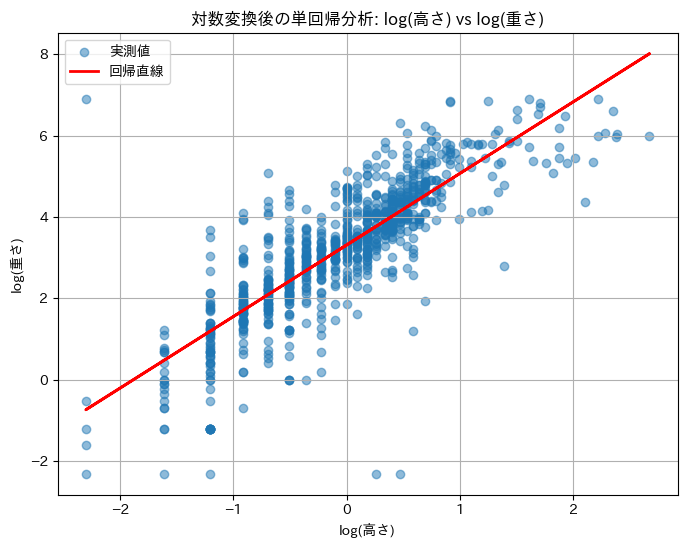

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


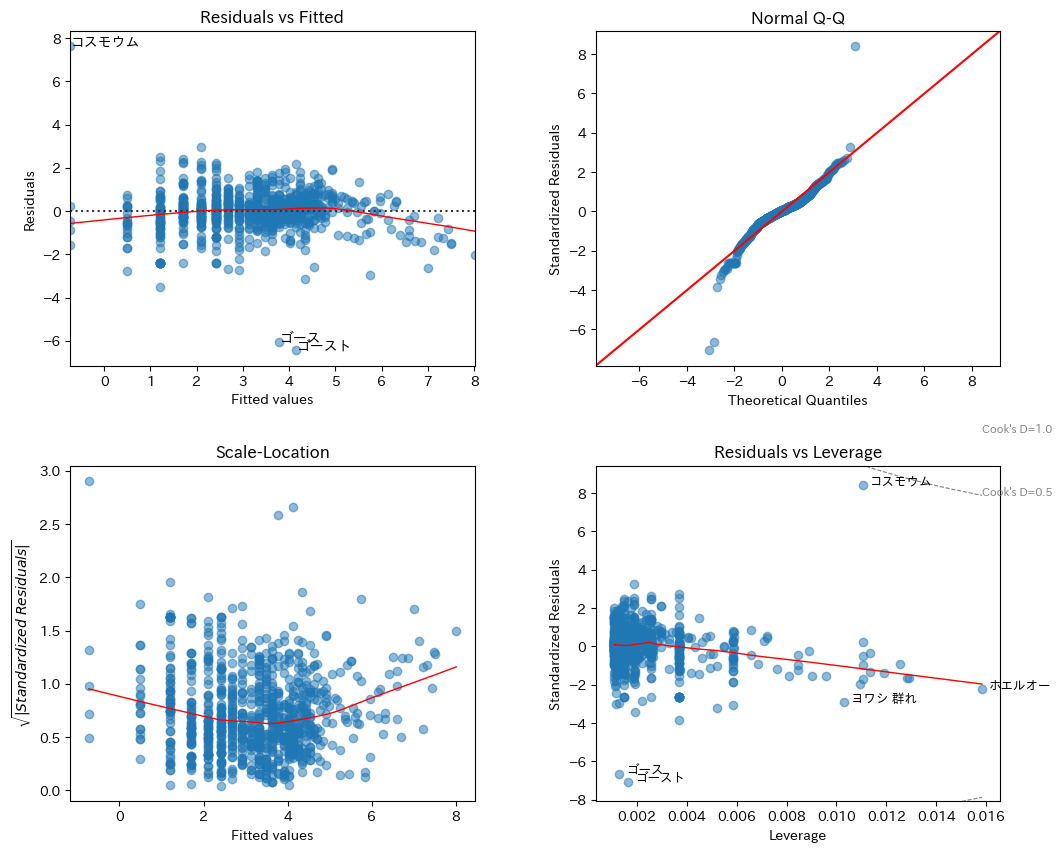

In [ ]:
#体重は高さの3乗に比例することに対しての両対数単回帰分析
#回帰診断
data_log = df[['高さ', '重さ']]
data_log['log_height'] = np.log(data_log['高さ'])
data_log['log_weight'] = np.log(data_log['重さ'])
y = data_log['log_weight']
X = data_log['log_height']
X_const = sm.add_constant(X)
model_log = sm.OLS(y, X_const).fit()
print(model_log.summary())
#可視化
plt.figure(figsize=(8, 6))
plt.scatter(data_log['log_height'], data_log['log_weight'], alpha=0.5, label='実測値')
plt.plot(data_log['log_height'], model_log.predict(X_const), color='red', linewidth=2, label='回帰直線')
plt.xlabel('log(高さ)')
plt.ylabel('log(重さ)')
plt.title('対数変換後の単回帰分析: log(高さ) vs log(重さ)')
plt.legend()
plt.grid(True) # グリッド線を表示
plt.show()
#診断
names = df['名前']
def plot_lm_diagnostics_enhanced(model, labels=None):
    # 統計量の取得
    fitted = model.fittedvalues
    residuals = model.resid
    norm_residuals = model.get_influence().resid_studentized_internal
    norm_residuals_abs_sqrt = np.sqrt(np.abs(norm_residuals))
    leverage = model.get_influence().hat_matrix_diag
    cooks = model.get_influence().cooks_distance[0]

    # プロット枠の作成
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # --- 共通処理: 上位の外れ値にラベルを貼る関数 ---
    def annotate_outliers(x, y, ax, n=3):
        if labels is None: return
        # Cookの距離が大きい順にn個選ぶ
        top_indices = np.argsort(cooks)[-n:]
        for i in top_indices:
            ax.annotate(labels.iloc[i],
                        xy=(x[i], y[i]),
                        xytext=(5, 0), textcoords='offset points',
                        color='black', fontsize=9)

    # 1. Residuals vs Fitted
    sns.residplot(x=fitted, y=residuals, lowess=True,
                  scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1}, ax=axes[0, 0])
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')
    # 残差の絶対値が大きい順にラベル表示
    top_resid = np.argsort(np.abs(residuals))[-3:]
    for i in top_resid:
        axes[0, 0].annotate(labels.iloc[i], xy=(fitted[i], residuals[i]))

    # 2. Normal Q-Q
    QQ = ProbPlot(norm_residuals)
    QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1, ax=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')
    axes[0, 1].set_xlabel('Theoretical Quantiles')
    axes[0, 1].set_ylabel('Standardized Residuals')

    # 3. Scale-Location
    axes[1, 0].scatter(fitted, norm_residuals_abs_sqrt, alpha=0.5)
    sns.regplot(x=fitted, y=norm_residuals_abs_sqrt, scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1}, ax=axes[1, 0])
    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')

    # 4. Residuals vs Leverage (Cook's Distance Contours 追加)
    axes[1, 1].scatter(leverage, norm_residuals, alpha=0.5)
    sns.regplot(x=leverage, y=norm_residuals, scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1}, ax=axes[1, 1])

    # --- Cookの距離の等高線を描画 ---
    p = len(model.params) # パラメータ数
    x_pos = np.linspace(min(leverage)+0.001, max(leverage), 100)

    # 等高線の数式: Standardized Residuals = sqrt(CookD * p * (1-h)/h)
    def r_cooks(D, x, p):
        return np.sqrt(D * p * (1 - x) / x)

    # 0.5 と 1.0 のラインを描画
    for D in [0.5, 1.0]:
        y_pos = r_cooks(D, x_pos, p)
        axes[1, 1].plot(x_pos, y_pos, linestyle='--', color='gray', linewidth=0.8)      # 上側
        axes[1, 1].plot(x_pos, -y_pos, linestyle='--', color='gray', linewidth=0.8)     # 下側
        # 端っこにテキスト表示
        if not np.isnan(y_pos[-1]):
             axes[1, 1].text(x_pos[-1], y_pos[-1], f'Cook\'s D={D}', fontsize=8, color='gray')

    axes[1, 1].set_title('Residuals vs Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Standardized Residuals')
    axes[1, 1].set_ylim(min(norm_residuals)-1, max(norm_residuals)+1)

    # 外れ値（影響力が大きい点）のラベル表示
    annotate_outliers(leverage, norm_residuals, axes[1, 1], n=5)

    plt.show()

plot_lm_diagnostics_enhanced(model_log, names)

<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-670785893.py:60: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')


                            OLS Regression Results                            
Dep. Variable:                     素早   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     25.44
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           8.22e-16
Time:                        13:03:33   Log-Likelihood:                -4379.2
No. Observations:                 920   AIC:                             8766.
Df Residuals:                     916   BIC:                             8786.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.3020      2.920     19.627      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


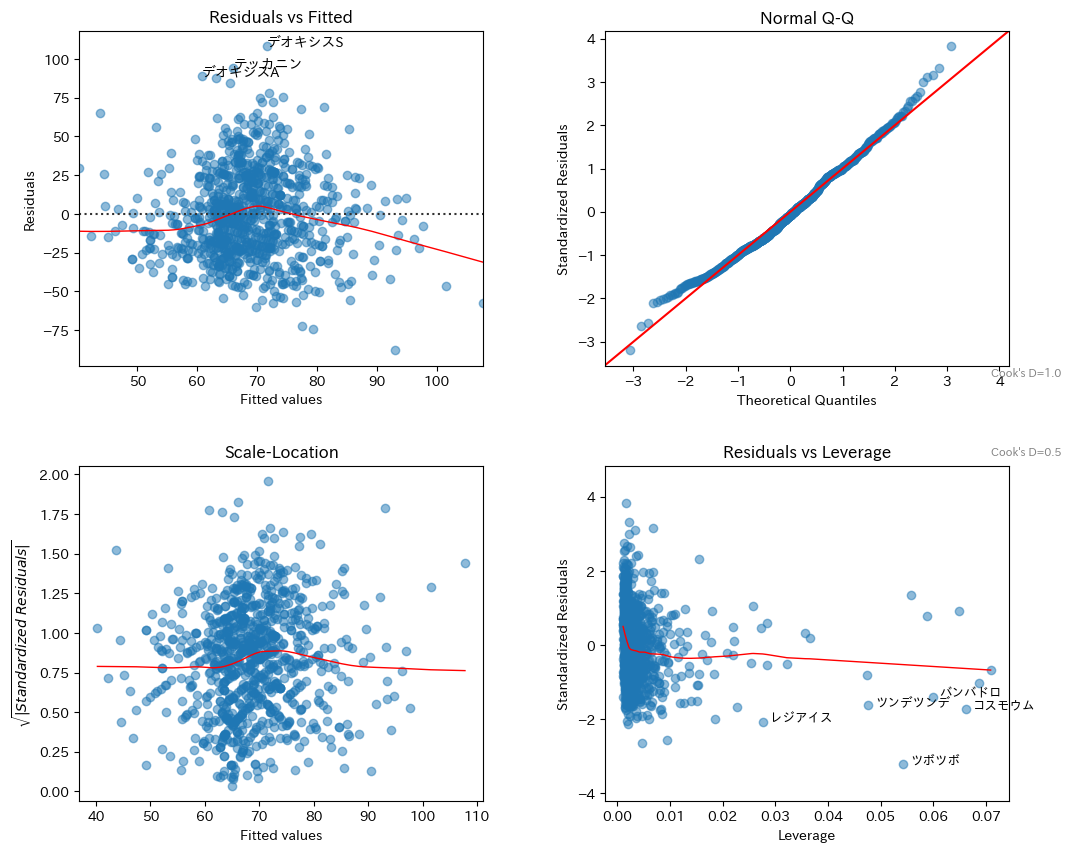

In [ ]:
#重回帰分析statsmodels
#素早を目的変数に、重さと防御、特防を説明変数に。つまり硬くて重いポケモンは遅い。
#データ加工
data_mlr = df[['素早', '重さ', '防御', '特防']]
y_mlr = data_mlr['素早']
X_mlr = data_mlr[['重さ', '防御', '特防']]
#検定
X_mlr_const = sm.add_constant(X_mlr)
model_mlr = sm.OLS(y_mlr, X_mlr_const).fit()
print(model_mlr.summary())
names = df['名前']
def plot_lm_diagnostics_enhanced(model, labels=None):
    # 統計量の取得
    fitted = model.fittedvalues
    residuals = model.resid
    norm_residuals = model.get_influence().resid_studentized_internal
    norm_residuals_abs_sqrt = np.sqrt(np.abs(norm_residuals))
    leverage = model.get_influence().hat_matrix_diag
    cooks = model.get_influence().cooks_distance[0]

    # プロット枠の作成
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # --- 共通処理: 上位の外れ値にラベルを貼る関数 ---
    def annotate_outliers(x, y, ax, n=3):
        if labels is None: return
        # Cookの距離が大きい順にn個選ぶ
        top_indices = np.argsort(cooks)[-n:]
        for i in top_indices:
            ax.annotate(labels.iloc[i],
                        xy=(x[i], y[i]),
                        xytext=(5, 0), textcoords='offset points',
                        color='black', fontsize=9)

    # 1. Residuals vs Fitted
    sns.residplot(x=fitted, y=residuals, lowess=True,
                  scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1}, ax=axes[0, 0])
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')
    # 残差の絶対値が大きい順にラベル表示
    top_resid = np.argsort(np.abs(residuals))[-3:]
    for i in top_resid:
        axes[0, 0].annotate(labels.iloc[i], xy=(fitted[i], residuals[i]))

    # 2. Normal Q-Q
    QQ = ProbPlot(norm_residuals)
    QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1, ax=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')
    axes[0, 1].set_xlabel('Theoretical Quantiles')
    axes[0, 1].set_ylabel('Standardized Residuals')

    # 3. Scale-Location
    axes[1, 0].scatter(fitted, norm_residuals_abs_sqrt, alpha=0.5)
    sns.regplot(x=fitted, y=norm_residuals_abs_sqrt, scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1}, ax=axes[1, 0])
    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')

    # 4. Residuals vs Leverage (Cook's Distance Contours 追加)
    axes[1, 1].scatter(leverage, norm_residuals, alpha=0.5)
    sns.regplot(x=leverage, y=norm_residuals, scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1}, ax=axes[1, 1])

    # --- Cookの距離の等高線を描画 ---
    p = len(model.params) # パラメータ数
    x_pos = np.linspace(min(leverage)+0.001, max(leverage), 100)

    # 等高線の数式: Standardized Residuals = sqrt(CookD * p * (1-h)/h)
    def r_cooks(D, x, p):
        return np.sqrt(D * p * (1 - x) / x)

    # 0.5 と 1.0 のラインを描画
    for D in [0.5, 1.0]:
        y_pos = r_cooks(D, x_pos, p)
        axes[1, 1].plot(x_pos, y_pos, linestyle='--', color='gray', linewidth=0.8)      # 上側
        axes[1, 1].plot(x_pos, -y_pos, linestyle='--', color='gray', linewidth=0.8)     # 下側
        # 端っこにテキスト表示
        if not np.isnan(y_pos[-1]):
             axes[1, 1].text(x_pos[-1], y_pos[-1], f'Cook\'s D={D}', fontsize=8, color='gray')

    axes[1, 1].set_title('Residuals vs Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Standardized Residuals')
    axes[1, 1].set_ylim(min(norm_residuals)-1, max(norm_residuals)+1)

    # 外れ値（影響力が大きい点）のラベル表示
    annotate_outliers(leverage, norm_residuals, axes[1, 1], n=5)

    plt.show()

plot_lm_diagnostics_enhanced(model_mlr, names)

最適なalpha (Ridge): 18.4207
最適なalpha (Lasso): 0.1677

--- 回帰係数の比較 ---


,項目,通常(OLS),Ridge,Lasso
0,HP,-2.435822,-2.032032,-1.962665
1,攻撃,11.768414,11.114223,11.316738
2,防御,-9.398652,-8.744350,-8.920832
3,特攻,8.626221,8.544383,8.633902
4,特防,4.680390,4.275389,4.230238
5,高さ,0.341631,0.356589,0.000000
6,重さ,-2.176690,-2.191674,-1.896911


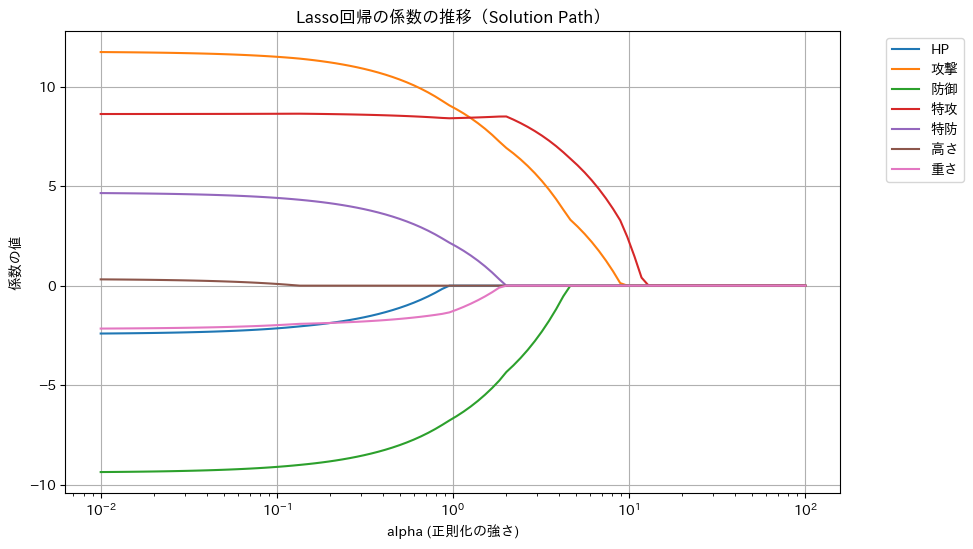

In [ ]:
#ridge,lasso回帰分析
features_rl = ['HP', '攻撃', '防御', '特攻', '特防', '高さ', '重さ']
target_rl = '素早'
data_rl = df[features_rl + [target_rl]]
X = data_rl[features_rl]
y = data_rl[target_rl]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features_rl)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Ridge回帰
ridge = RidgeCV(alphas=np.logspace(-2, 2, 50))
ridge.fit(X_train, y_train)

# Lasso回帰
lasso = LassoCV(alphas=np.logspace(-2, 2, 50), cv=5)
lasso.fit(X_train, y_train)

# 線形回帰
lr = LinearRegression()
lr.fit(X_train, y_train)

coef_df = pd.DataFrame({
    '項目': features_rl,
    '通常(OLS)': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print(f"最適なalpha (Ridge): {ridge.alpha_:.4f}")
print(f"最適なalpha (Lasso): {lasso.alpha_:.4f}")
print("\n--- 回帰係数の比較 ---")
display(coef_df)

alphas = np.logspace(-2, 2, 100)
coefs = []
for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log') # 横軸を対数スケールに
plt.xlabel('alpha (正則化の強さ)')
plt.ylabel('係数の値')
plt.title('Lasso回帰の係数の推移（Solution Path）')
plt.legend(features_rl, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

いわタイプの数: 69
それ以外の数: 851
Optimization terminated successfully.
         Current function value: 0.217042
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                is_rock   No. Observations:                  920
Model:                          Logit   Df Residuals:                      913
Method:                           MLE   Df Model:                            6
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                  0.1852
Time:                        08:01:19   Log-Likelihood:                -199.68
converged:                       True   LL-Null:                       -245.07
Covariance Type:            nonrobust   LLR p-value:                 2.076e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9195      0.565     -5.170      0.000      -4.026      -1.813
HP   

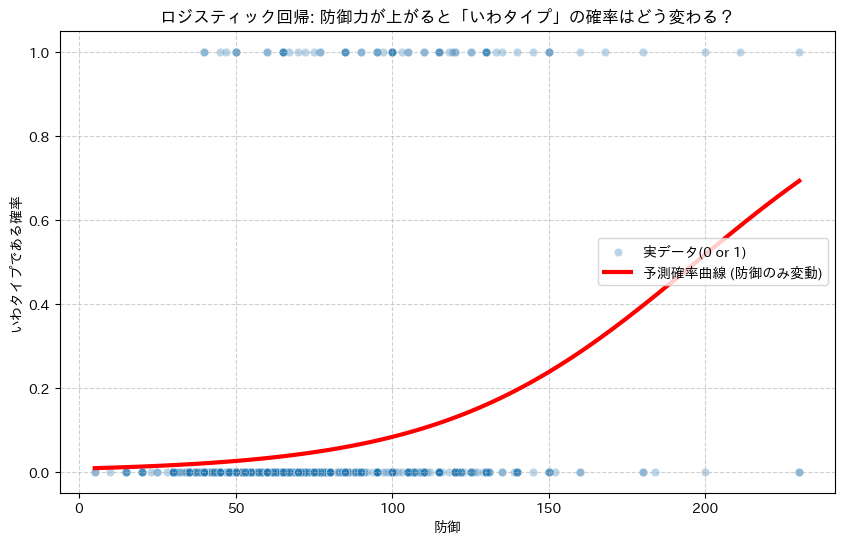

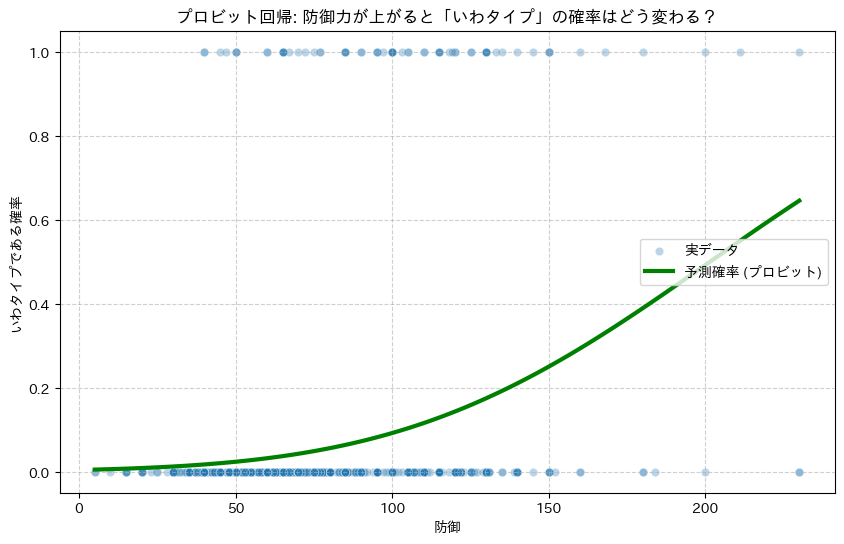

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


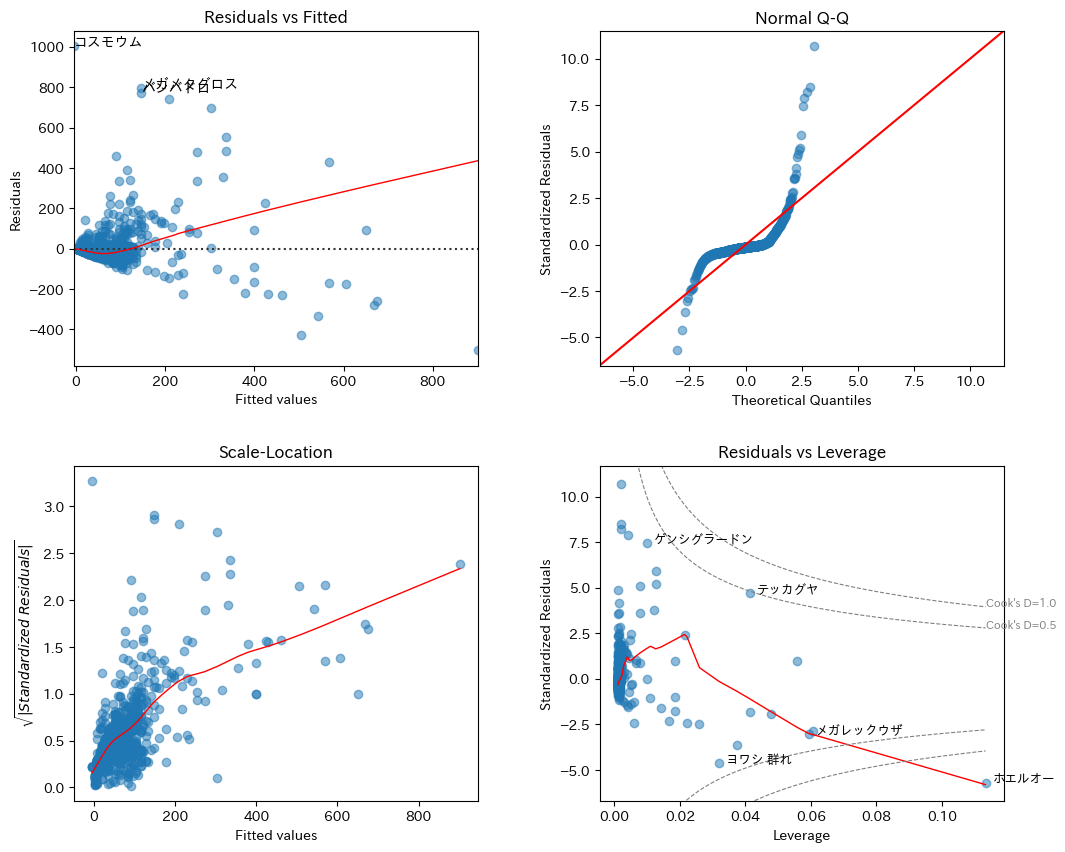

In [ ]:
#18章質的回帰
#ロジスティクス回帰分析とプロビット回帰分析
#岩タイプかどうか
#データ加工
dfr = df.copy()
dfr['is_rock'] = dfr.apply(lambda x: 1 if (x['タイプ1'] == 'いわ') or (x['タイプ2'] == 'いわ') else 0, axis=1)
print("いわタイプの数:", dfr['is_rock'].sum())
print("それ以外の数:", len(df) - dfr['is_rock'].sum())
y = dfr['is_rock']
feature_cols_rg = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df[feature_cols_rg]
X_const = sm.add_constant(X)
#検定
model = sm.Logit(y, X_const)
results = model.fit()
print(results.summary())
odds_ratios = np.exp(results.params)
print("\n【オッズ比 (Odds Ratios)】")
print(odds_ratios)
print("\n解釈: 1より大きければ、その数値が上がると『いわタイプ』である確率が高まる")
model_probit = sm.Probit(y, X_const)
results_probit = model_probit.fit()
print("【プロビット回帰分析結果】")
print(results_probit.summary())
margeff = results_probit.get_margeff()
print("\n【限界効果 (Marginal Effects)】")
print(margeff.summary())
#図示
plt.figure(figsize=(10, 6))
# 予測用データ作成
def_range = np.linspace(X['防御'].min(), X['防御'].max(), 100)
X_pred = pd.DataFrame({
    'const': 1.0,
    'HP': X['HP'].mean(),
    '攻撃': X['攻撃'].mean(),
    '防御': def_range,         # ここだけ動かす
    '特攻': X['特攻'].mean(),
    '特防': X['特防'].mean(),
    '素早': X['素早'].mean()
})

# 確率を予測
y_prob_pred = results.predict(X_pred)
# プロット
sns.scatterplot(x=df['防御'], y=dfr['is_rock'], alpha=0.3, label='実データ(0 or 1)')
plt.plot(def_range, y_prob_pred, color='red', linewidth=3, label='予測確率曲線 (防御のみ変動)')
plt.title('ロジスティック回帰: 防御力が上がると「いわタイプ」の確率はどう変わる？')
plt.xlabel('防御')
plt.ylabel('いわタイプである確率')
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 6))
# 予測用データ作成 (防御以外は平均値固定)
def_range = np.linspace(X['防御'].min(), X['防御'].max(), 100)
X_pred = pd.DataFrame({
    'const': 1.0,
    'HP': X['HP'].mean(),
    '攻撃': X['攻撃'].mean(),
    '防御': def_range,
    '特攻': X['特攻'].mean(),
    '特防': X['特防'].mean(),
    '素早': X['素早'].mean()
})

# 確率を予測
y_prob_pred = results_probit.predict(X_pred)

# プロット
sns.scatterplot(x=df['防御'], y=dfr['is_rock'], alpha=0.3, label='実データ')
plt.plot(def_range, y_prob_pred, color='green', linewidth=3, label='予測確率 (プロビット)')

plt.title('プロビット回帰: 防御力が上がると「いわタイプ」の確率はどう変わる？')
plt.xlabel('防御')
plt.ylabel('いわタイプである確率')
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plot_lm_diagnostics_enhanced(model_slr, names)


In [ ]:
#20章分散分析
#一元配置分散分析
#草、炎、水と成長に必要な経験値量によって分散に差はあるか
#データ加工
target_types_anova = ['くさ', 'ほのお', 'みず']
top_growth_rates = ['100万', '106万']
df_anova = df[
    (df['タイプ1'].isin(target_types_anova)) &
    (df['成長'].isin(top_growth_rates))
].copy()

print(f"分析対象データ数: {len(df_anova)}")
print("クロス集計表:")
print(pd.crosstab(df_anova['タイプ1'], df_anova['成長']))
groups = [df_anova[df_anova['タイプ1'] == t]['合計種族値'] for t in target_types_anova]
f_stat, p_val = stats.f_oneway(*groups)

print("\n" + "="*50)
print("一元配置分散分析 (タイプ1 -> 合計種族値)")
print("="*50)
print(f"F値    : {f_stat:.4f}")
print(f"P値    : {p_val:.4f}")

分析対象データ数: 196
クロス集計表:
成長    100万  106万
タイプ1            
くさ      22    48
ほのお     20    31
みず      41    34

一元配置分散分析 (タイプ1 -> 合計種族値)
F値    : 1.5368
P値    : 0.2177



二元配置分散分析 (タイプ1 × 成長 -> 合計種族値)
                     sum_sq     df         F    PR(>F)
C(タイプ1)        3.377358e+04    2.0  1.560875  0.212632
C(成長)          7.119286e+03    1.0  0.658048  0.418265
C(タイプ1):C(成長)  2.337480e+03    2.0  0.108029  0.897657
Residual       2.055572e+06  190.0       NaN       NaN


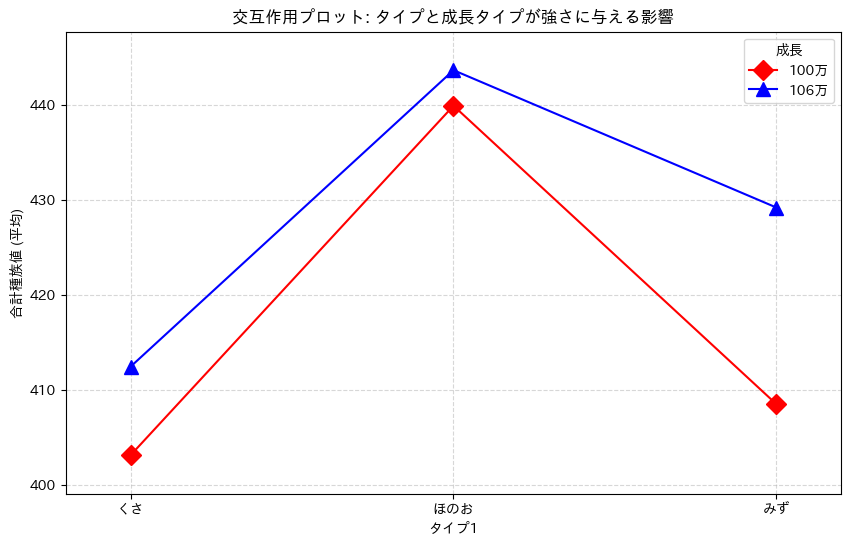

In [ ]:
#二元配置分散分析
model = ols('合計種族値 ~ C(タイプ1) + C(成長) + C(タイプ1):C(成長)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n" + "="*50)
print("二元配置分散分析 (タイプ1 × 成長 -> 合計種族値)")
print("="*50)
print(anova_table)
#図示
plt.figure(figsize=(10, 6))
interaction_plot(
    x=df_anova['タイプ1'],
    trace=df_anova['成長'],
    response=df_anova['合計種族値'],
    colors=['red', 'blue'],
    markers=['D', '^'],
    ms=10,
    ax=plt.gca()
)

plt.title('交互作用プロット: タイプと成長タイプが強さに与える影響')
plt.xlabel('タイプ1')
plt.ylabel('合計種族値 (平均)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

母集団サイズ (N): 915
真の合計種族値の母平均 (mu): 438.25

【配分計画】
      Nh     sigma_h  n_prop  n_neyman
タイプ1                                  
あく    36  111.264022       4         4
いわ    55  104.882159       6         5
かくとう  31  103.304863       3         3
くさ    83  109.670905       9         9
こおり   28  108.321214       3         3


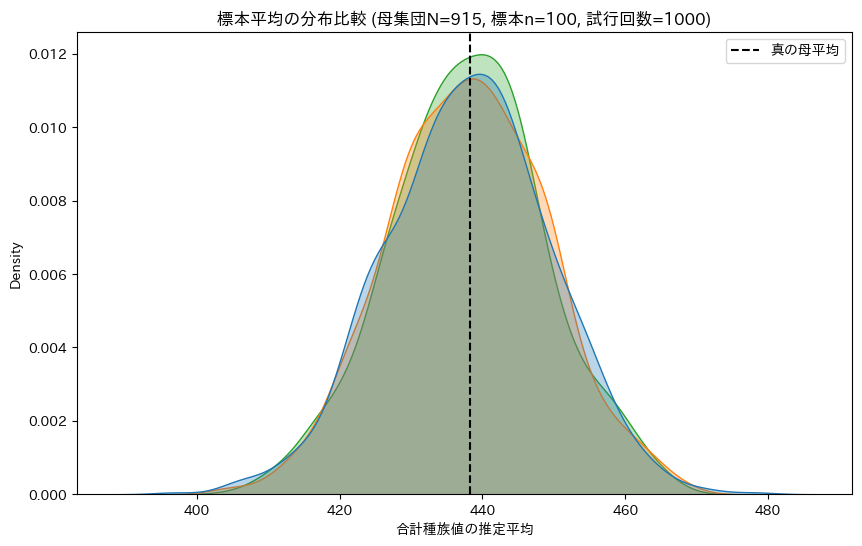


【シミュレーション結果: 標準誤差の比較】
              mean        std
Method                       
単純無作為   437.965720  11.438063
比例配分    437.963092  11.041481
ネイマン配分  437.952951  10.846860


In [ ]:
#21章標本調査法
#単純無作為抽出、比例配分、ネイマン配分でタイプから抽出
#データ加工
type_counts = df['タイプ1'].value_counts()
valid_types = type_counts[type_counts >= 10].index
df_pop = df[df['タイプ1'].isin(valid_types)].copy()
target_col_sm = '合計種族値'
strata_col = 'タイプ1'
N = len(df_pop)
mu = df_pop[target_col_sm].mean()
print(f"母集団サイズ (N): {N}")
print(f"真の合計種族値の母平均 (mu): {mu:.2f}")
strata_stats = df_pop.groupby(strata_col)[target_col_sm].agg(['count', 'std', 'mean'])
strata_stats.rename(columns={'count': 'Nh', 'std': 'sigma_h', 'mean': 'mu_h'}, inplace=True)
n_total = 100
strata_stats['n_prop'] = (n_total * (strata_stats['Nh'] / N)).round().astype(int)
diff = n_total - strata_stats['n_prop'].sum()
if diff != 0:
    max_idx = strata_stats['Nh'].idxmax()
    strata_stats.loc[max_idx, 'n_prop'] += diff
numerator = strata_stats['Nh'] * strata_stats['sigma_h']
denominator = numerator.sum()
strata_stats['n_neyman'] = (n_total * (numerator / denominator)).round().astype(int)
diff_neyman = n_total - strata_stats['n_neyman'].sum()
if diff_neyman != 0:
    max_idx = strata_stats['Nh'].idxmax()
    strata_stats.loc[max_idx, 'n_neyman'] += diff_neyman
strata_stats['n_neyman'] = strata_stats['n_neyman'].clip(lower=1)

print("\n【配分計画】")
print(strata_stats[['Nh', 'sigma_h', 'n_prop', 'n_neyman']].head())
n_simulations = 1000
results = {'Method': [], 'Estimate': []}

np.random.seed(42)

for i in range(n_simulations):
    # (1) 単純無作為抽出 (SRS)
    sample_srs = df_pop[target_col_sm].sample(n=n_total)
    results['Method'].append('単純無作為')
    results['Estimate'].append(sample_srs.mean())

    # (2) 層化抽出 (比例配分)
    weighted_sum_prop = 0
    for stratum, row in strata_stats.iterrows():
        n_h = int(row['n_prop'])
        if n_h > 0:
            # 各層からランダム抽出
            subset_samp = df_pop[df_pop[strata_col] == stratum][target_col_sm].sample(n=n_h, replace=False)
            # 層別平均 × 層の重み (Nh) を加算
            weighted_sum_prop += row['Nh'] * subset_samp.mean()
    results['Method'].append('比例配分')
    results['Estimate'].append(weighted_sum_prop / N)

    # (3) 層化抽出 (ネイマン配分)
    weighted_sum_neyman = 0
    for stratum, row in strata_stats.iterrows():
        n_h = int(row['n_neyman'])
        if n_h > 0:
            subset_samp = df_pop[df_pop[strata_col] == stratum][target_col_sm].sample(n=n_h, replace=False)
            weighted_sum_neyman += row['Nh'] * subset_samp.mean()
    results['Method'].append('ネイマン配分')
    results['Estimate'].append(weighted_sum_neyman / N)
#図示
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
# 分布（カーネル密度推定）を描画
sns.kdeplot(data=results_df, x='Estimate', hue='Method', fill=True, alpha=0.3)
plt.axvline(mu, color='black', linestyle='--', label='真の母平均')
plt.title(f'標本平均の分布比較 (母集団N={N}, 標本n={n_total}, 試行回数={n_simulations})')
plt.xlabel('合計種族値の推定平均')
plt.legend()
plt.show()

# 標準誤差（標準偏差）の確認
print("\n【シミュレーション結果: 標準誤差の比較】")
print(results_df.groupby('Method')['Estimate'].agg(['mean', 'std']).sort_values('std', ascending=False))

【主成分分析の結果一覧】
   主成分       固有値       寄与率     累積寄与率
0  PC1  2.689330  0.447735  0.447735
1  PC2  1.132133  0.188484  0.636218
2  PC3  0.786868  0.131002  0.767220
3  PC4  0.715785  0.119168  0.886388
4  PC5  0.421383  0.070154  0.956542
5  PC6  0.261029  0.043458  1.000000

【因子負荷量 (Loadings)】
         PC1       PC2
HP  0.395573 -0.063949
攻撃  0.440210  0.023525
防御  0.369686 -0.615301
特攻  0.458214  0.300991
特防  0.448888 -0.250605
素早  0.318762  0.680709

結果の解釈:
PC1は全ての係数がプラス -> 「総合的な強さ」を表す
PC2は防御がプラス、素早さがマイナス -> 「耐久型 vs 速攻型」を表す


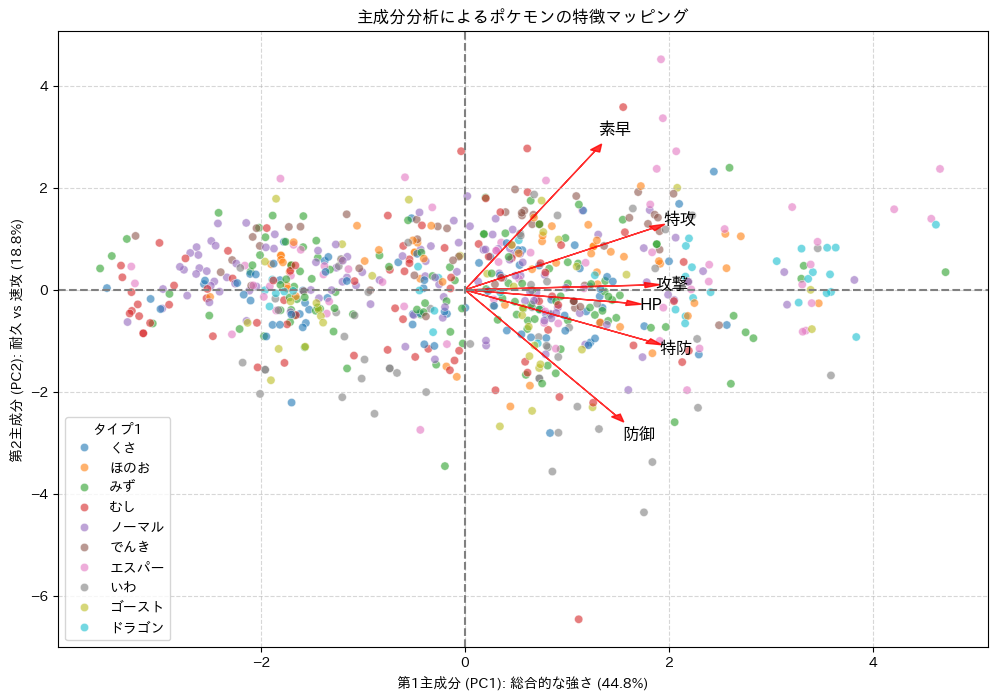

In [ ]:
#22章主成分分析
#種族値でポケモンを説明する
#データ加工
feature_cols_pca = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df[feature_cols_pca]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#主成分分析
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
final_df = pd.concat([pca_df, df[['名前', 'タイプ1']]], axis=1)
pca_all = PCA()
pca_all.fit(X_scaled)
eigenvalues = pca_all.explained_variance_
variance_ratios = pca_all.explained_variance_ratio_
cumulative_variance_ratios = np.cumsum(variance_ratios)
#結果
pca_summary = pd.DataFrame({
    '主成分': [f'PC{i+1}' for i in range(len(eigenvalues))],
    '固有値': eigenvalues,
    '寄与率': variance_ratios,
    '累積寄与率': cumulative_variance_ratios
})

print("【主成分分析の結果一覧】")
print(pca_summary)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols_pca)
print("\n【因子負荷量 (Loadings)】")
print(loadings)
print("\n結果の解釈:")
print("PC1は全ての係数がプラス -> 「総合的な強さ」を表す")
print("PC2は防御がプラス、素早さがマイナス -> 「耐久型 vs 速攻型」を表す")
#図示
plt.figure(figsize=(12, 8))
top_types = df['タイプ1'].value_counts().index[:10]
sns.scatterplot(
    x='PC1', y='PC2',
    hue='タイプ1',
    data=final_df[final_df['タイプ1'].isin(top_types)],
    alpha=0.6,
    palette='tab10'
)
scale_factor = 4
for i, feature in enumerate(feature_cols_pca):
    arrow_x = loadings.iloc[i, 0] * scale_factor
    arrow_y = loadings.iloc[i, 1] * scale_factor

    plt.arrow(0, 0, arrow_x, arrow_y, color='red', alpha=0.8, head_width=0.1)
    plt.text(arrow_x * 1.15, arrow_y * 1.15, feature, color='black', ha='center', va='center', fontsize=12)

plt.title('主成分分析によるポケモンの特徴マッピング')
plt.xlabel(f'第1主成分 (PC1): 総合的な強さ ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'第2主成分 (PC2): 耐久 vs 速攻 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.show()

データ数: 115
タイプ1
むし      78
ドラゴン    37
Name: count, dtype: int64

【線形判別分析 (LDA) 結果】
正解率: 0.809
混同行列:
[[72  6]
 [16 21]]

判別係数（正ならドラゴン寄り、負ならむし寄りの傾向）:
            HP      攻撃        防御        特攻        特防       素早
判別係数  0.026345  0.0191 -0.015342  0.015516  0.017942 -0.01085

【二次判別分析 (QDA) 結果】
正解率: 0.835
混同行列:
[[75  3]
 [16 21]]


/tmp/ipython-input-1557863904.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loading', y='Feature', data=loadings_df, palette='viridis')


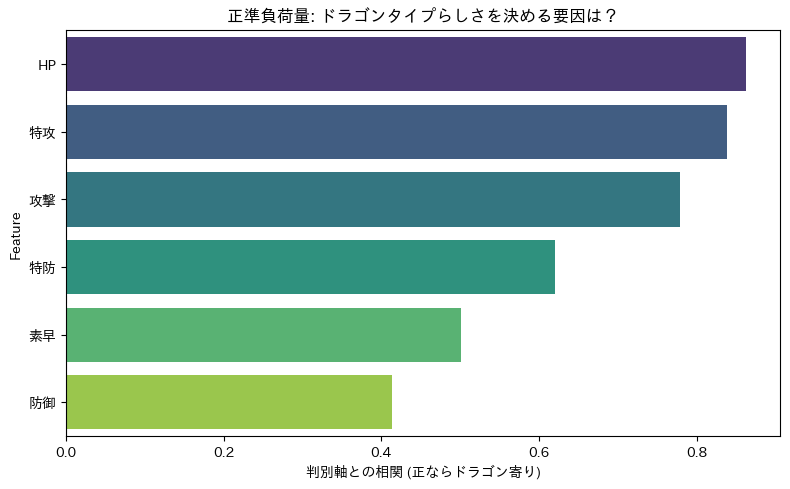

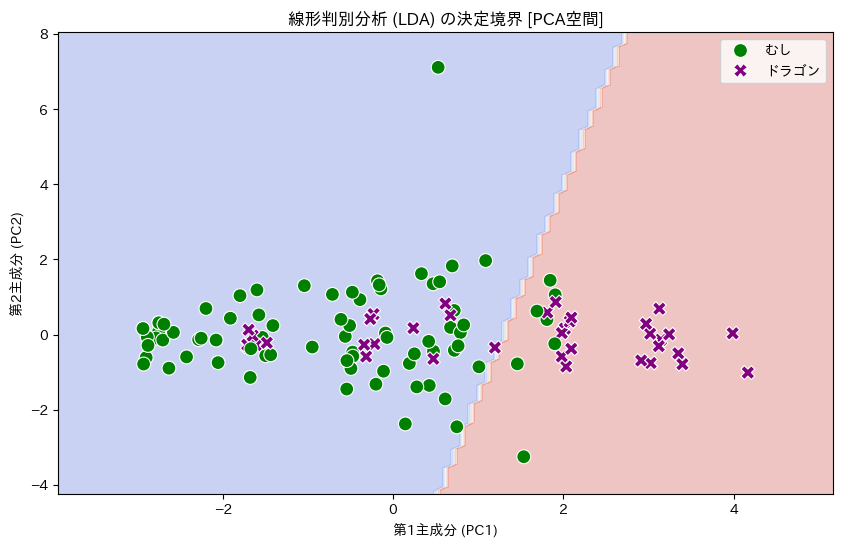

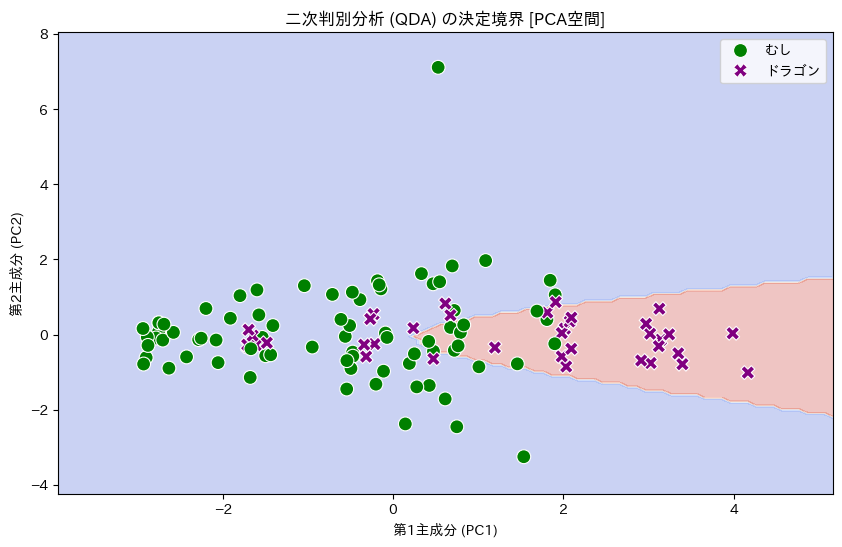

In [ ]:
#23章判別分析
#虫タイプとドラゴンタイプの判別
#データ加工
target_types_da = ['むし', 'ドラゴン']
df_disc_da = df[df['タイプ1'].isin(target_types_da)].copy()
feature_cols_da = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df_disc_da[feature_cols_da]
y = df_disc_da['タイプ1']
print(f"データ数: {len(X)}")
print(y.value_counts())
#フィッシャーの線形判別
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
y_pred_lda = lda.predict(X)
print("\n【線形判別分析 (LDA) 結果】")
print(f"正解率: {accuracy_score(y, y_pred_lda):.3f}")
print("混同行列:")
print(confusion_matrix(y, y_pred_lda, labels=target_types_da))
coef_df = pd.DataFrame(lda.coef_, columns=feature_cols_da, index=['判別係数'])
print("\n判別係数（正ならドラゴン寄り、負ならむし寄りの傾向）:")
print(coef_df)
#二次判別
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)
y_pred_qda = qda.predict(X)
print("\n【二次判別分析 (QDA) 結果】")
print(f"正解率: {accuracy_score(y, y_pred_qda):.3f}")
print("混同行列:")
print(confusion_matrix(y, y_pred_qda, labels=target_types_da))
#正準判別分析
lda_full = LinearDiscriminantAnalysis()
X_r1 = lda_full.fit_transform(X, y)
loadings = []
for col in feature_cols_da:
    corr = np.corrcoef(X[col], X_r1.ravel())[0, 1]
    loadings.append(corr)

loadings_df = pd.DataFrame({'Feature': feature_cols_da, 'Loading': loadings})
loadings_df = loadings_df.sort_values('Loading', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x='Loading', y='Feature', data=loadings_df, palette='viridis')
plt.title('正準負荷量: ドラゴンタイプらしさを決める要因は？')
plt.xlabel('判別軸との相関 (正ならドラゴン寄り)')
plt.axvline(0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()
#図示
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
lda_2d = LinearDiscriminantAnalysis()
lda_2d.fit(X_pca, y)
qda_2d = QuadraticDiscriminantAnalysis()
qda_2d.fit(X_pca, y)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z_lda = lda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_qda = qda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
classes = lda_2d.classes_ # ['むし', 'ドラゴン'] の順序
Z_lda_num = np.array([1 if c == classes[1] else 0 for c in Z_lda]).reshape(xx.shape)
Z_qda_num = np.array([1 if c == classes[1] else 0 for c in Z_qda]).reshape(xx.shape)
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_lda_num, alpha=0.3, cmap=plt.cm.coolwarm)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=y, palette=['green', 'purple'], s=100)
plt.title('線形判別分析 (LDA) の決定境界 [PCA空間]')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_qda_num, alpha=0.3, cmap=plt.cm.coolwarm)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=y, palette=['green', 'purple'], s=100)
plt.title('二次判別分析 (QDA) の決定境界 [PCA空間]')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.legend()
plt.show()

【線形SVM (Linear) の結果】
正解率: 0.835
混同行列:
[[76  2]
 [17 20]]

【非線形SVM (RBF) の結果】
正解率: 0.852
混同行列:
[[77  1]
 [16 21]]


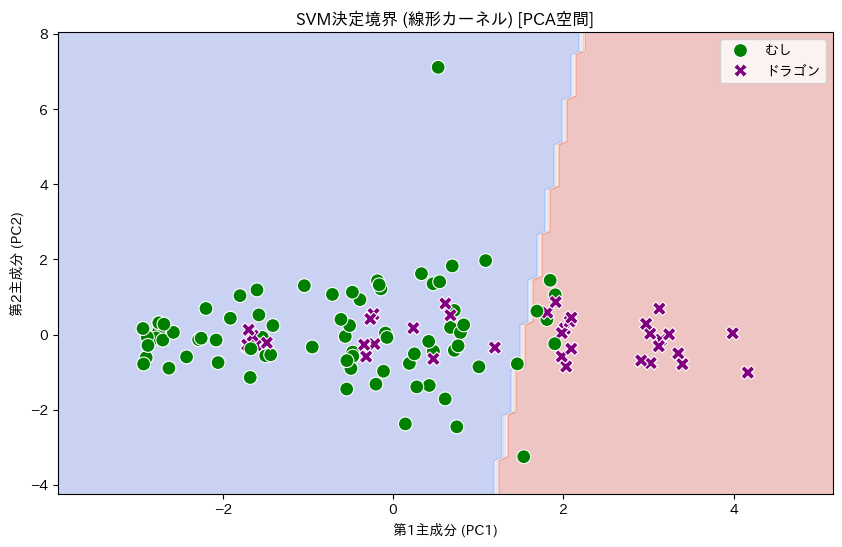

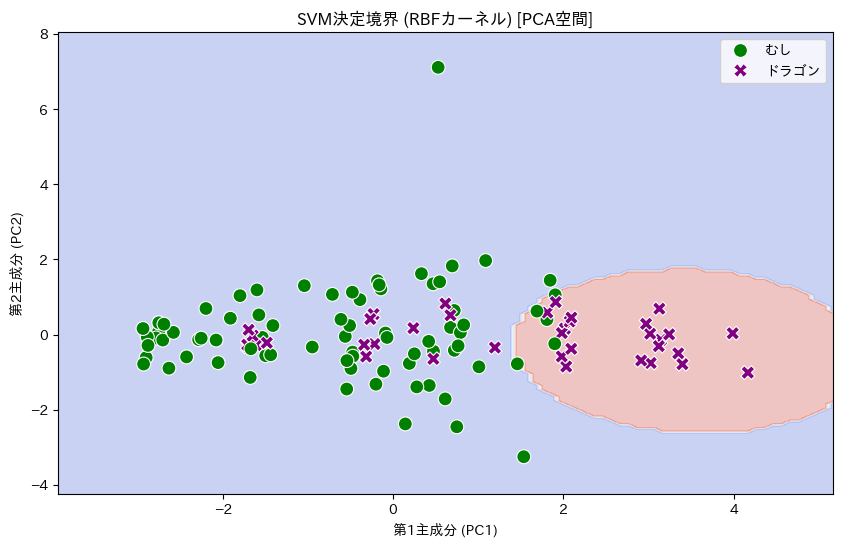

In [ ]:
#サポートベクターマシン
#データ加工
target_types_svm = ['むし', 'ドラゴン']
df_svm = df[df['タイプ1'].isin(target_types_svm)].copy()
feature_cols_svm = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df_svm[feature_cols_svm]
y = df_svm['タイプ1']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#線形カーネル
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_scaled, y)
y_pred_linear = svm_linear.predict(X_scaled)

print("【線形SVM (Linear) の結果】")
print(f"正解率: {accuracy_score(y, y_pred_linear):.3f}")
print("混同行列:")
print(confusion_matrix(y, y_pred_linear, labels=target_types_svm))
#非線形カーネル
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_scaled, y)
y_pred_rbf = svm_rbf.predict(X_scaled)
print("\n【非線形SVM (RBF) の結果】")
print(f"正解率: {accuracy_score(y, y_pred_rbf):.3f}")
print("混同行列:")
print(confusion_matrix(y, y_pred_rbf, labels=target_types_svm))
#図示
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
svm_viz_linear = SVC(kernel='linear', C=1.0)
svm_viz_linear.fit(X_pca, y)

svm_viz_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_viz_rbf.fit(X_pca, y)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z_linear = svm_viz_linear.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = svm_viz_rbf.predict(np.c_[xx.ravel(), yy.ravel()])

classes = svm_viz_linear.classes_
Z_linear_num = np.array([1 if c == classes[1] else 0 for c in Z_linear]).reshape(xx.shape)
Z_rbf_num = np.array([1 if c == classes[1] else 0 for c in Z_rbf]).reshape(xx.shape)
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_linear_num, alpha=0.3, cmap=plt.cm.coolwarm)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=y, palette=['green', 'purple'], s=100)
plt.title('SVM決定境界 (線形カーネル) [PCA空間]')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_rbf_num, alpha=0.3, cmap=plt.cm.coolwarm)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=y, palette=['green', 'purple'], s=100)
plt.title('SVM決定境界 (RBFカーネル) [PCA空間]')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.legend()
plt.show()

【混同行列】
TN (むし正解)    : 72
FP (むし誤検知)  : 6
FN (ドラゴン見逃し): 16
TP (ドラゴン正解)  : 21

【評価指標】
正解率 (Accuracy)       : 0.8087
適合率 (Precision)      : 0.7778
感度/再現率 (Recall)    : 0.5676
特異度 (Specificity)    : 0.9231
偽陽性率 (FPR)          : 0.0769
AUC                     : 0.8032


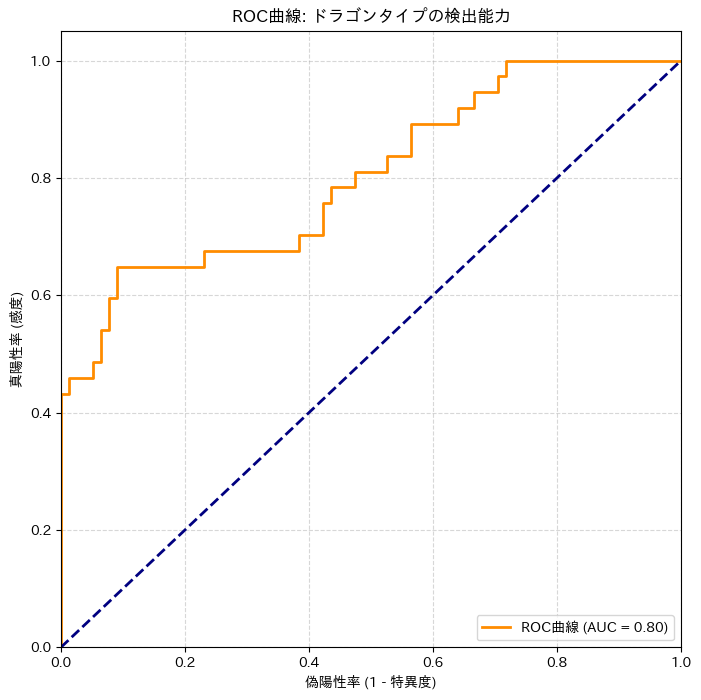

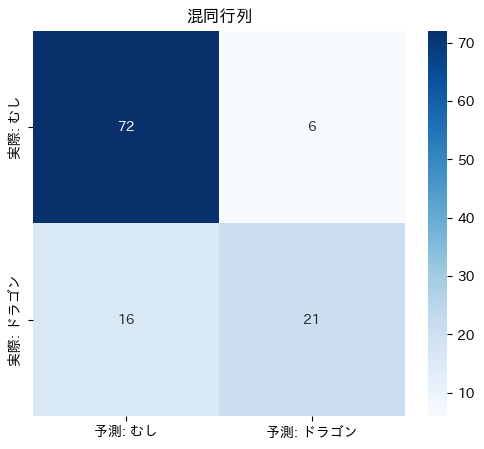

In [ ]:
#混同行列とROC曲線
#分析にはロジスティクス回帰分析を利用
#データ加工
target_types_cm = ['むし', 'ドラゴン']
df_roc = df[df['タイプ1'].isin(target_types_cm)].copy()
df_roc['target'] = df_roc['タイプ1'].map({'むし': 0, 'ドラゴン': 1})
feature_cols_cm = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df_roc[feature_cols_cm]
y = df_roc['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#ロジスティクス回帰分析
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_scaled, y)
y_pred = model_lr.predict(X_scaled)
y_prob = model_lr.predict_proba(X_scaled)[:, 1] # ドラゴンである確率
#計算
cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
specificity = tn / (tn + fp)
fpr = fp / (tn + fp)
print("【混同行列】")
print(f"TN (むし正解)    : {tn}")
print(f"FP (むし誤検知)  : {fp}")
print(f"FN (ドラゴン見逃し): {fn}")
print(f"TP (ドラゴン正解)  : {tp}")

print("\n【評価指標】")
print(f"正解率 (Accuracy)       : {accuracy:.4f}")
print(f"適合率 (Precision)      : {precision:.4f}")
print(f"感度/再現率 (Recall)    : {recall:.4f}")
print(f"特異度 (Specificity)    : {specificity:.4f}")
print(f"偽陽性率 (FPR)          : {fpr:.4f}")
#図示
fpr_vals, tpr_vals, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr_vals, tpr_vals)

print(f"AUC                     : {roc_auc:.4f}")

plt.figure(figsize=(8, 8))
plt.plot(fpr_vals, tpr_vals, color='darkorange', lw=2, label=f'ROC曲線 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('偽陽性率 (1 - 特異度)')
plt.ylabel('真陽性率 (感度)')
plt.title('ROC曲線: ドラゴンタイプの検出能力')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['予測: むし', '予測: ドラゴン'],
            yticklabels=['実際: むし', '実際: ドラゴン'])
plt.title('混同行列')
plt.show()

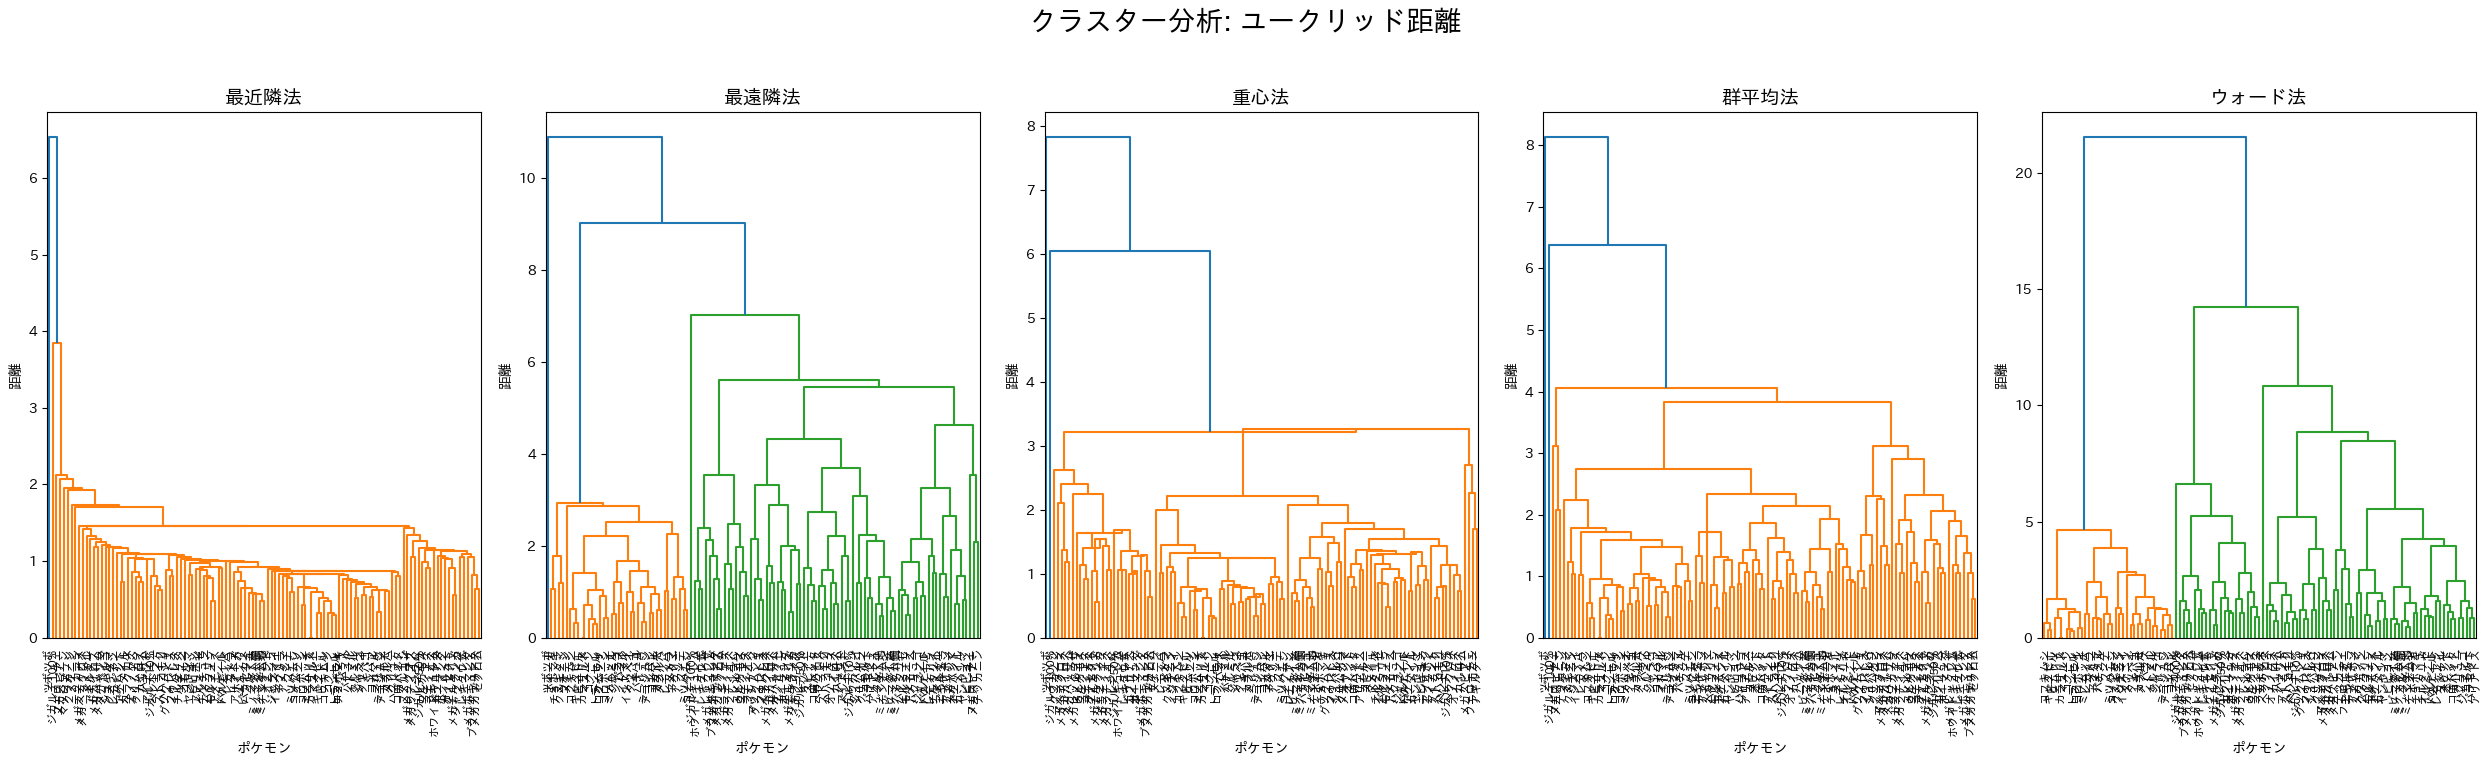

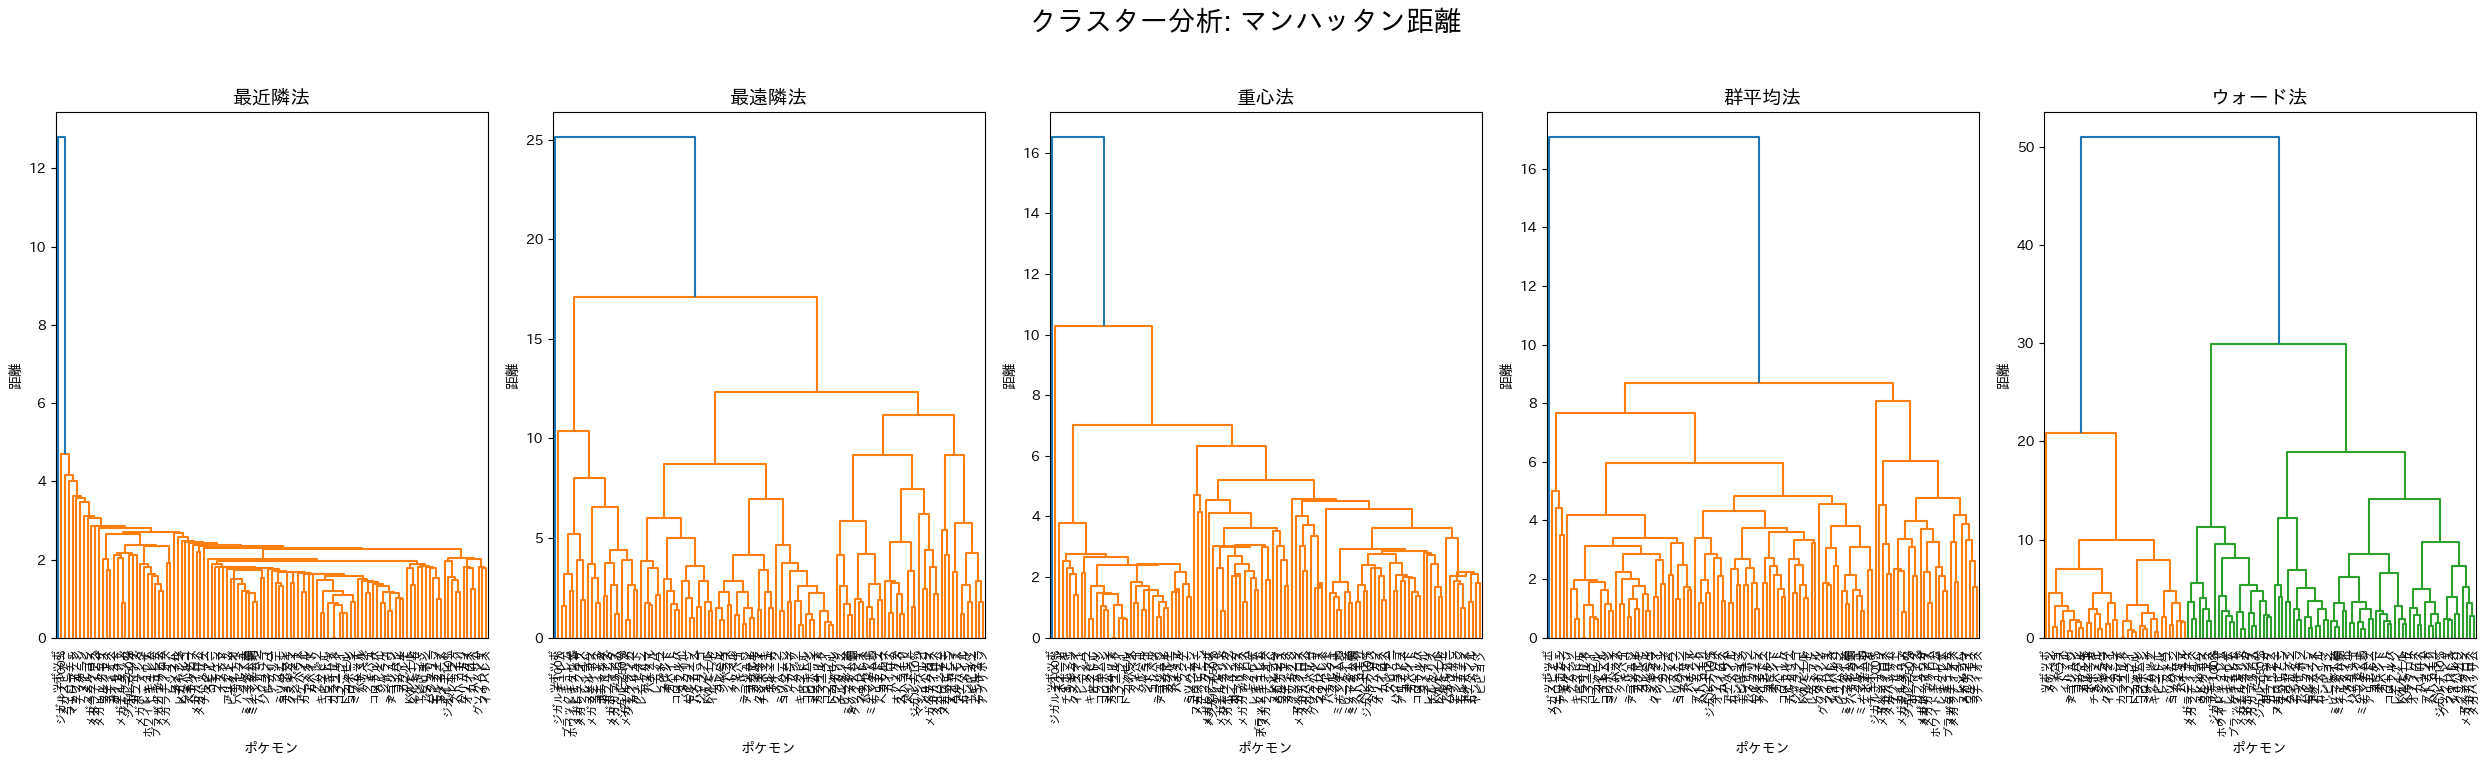

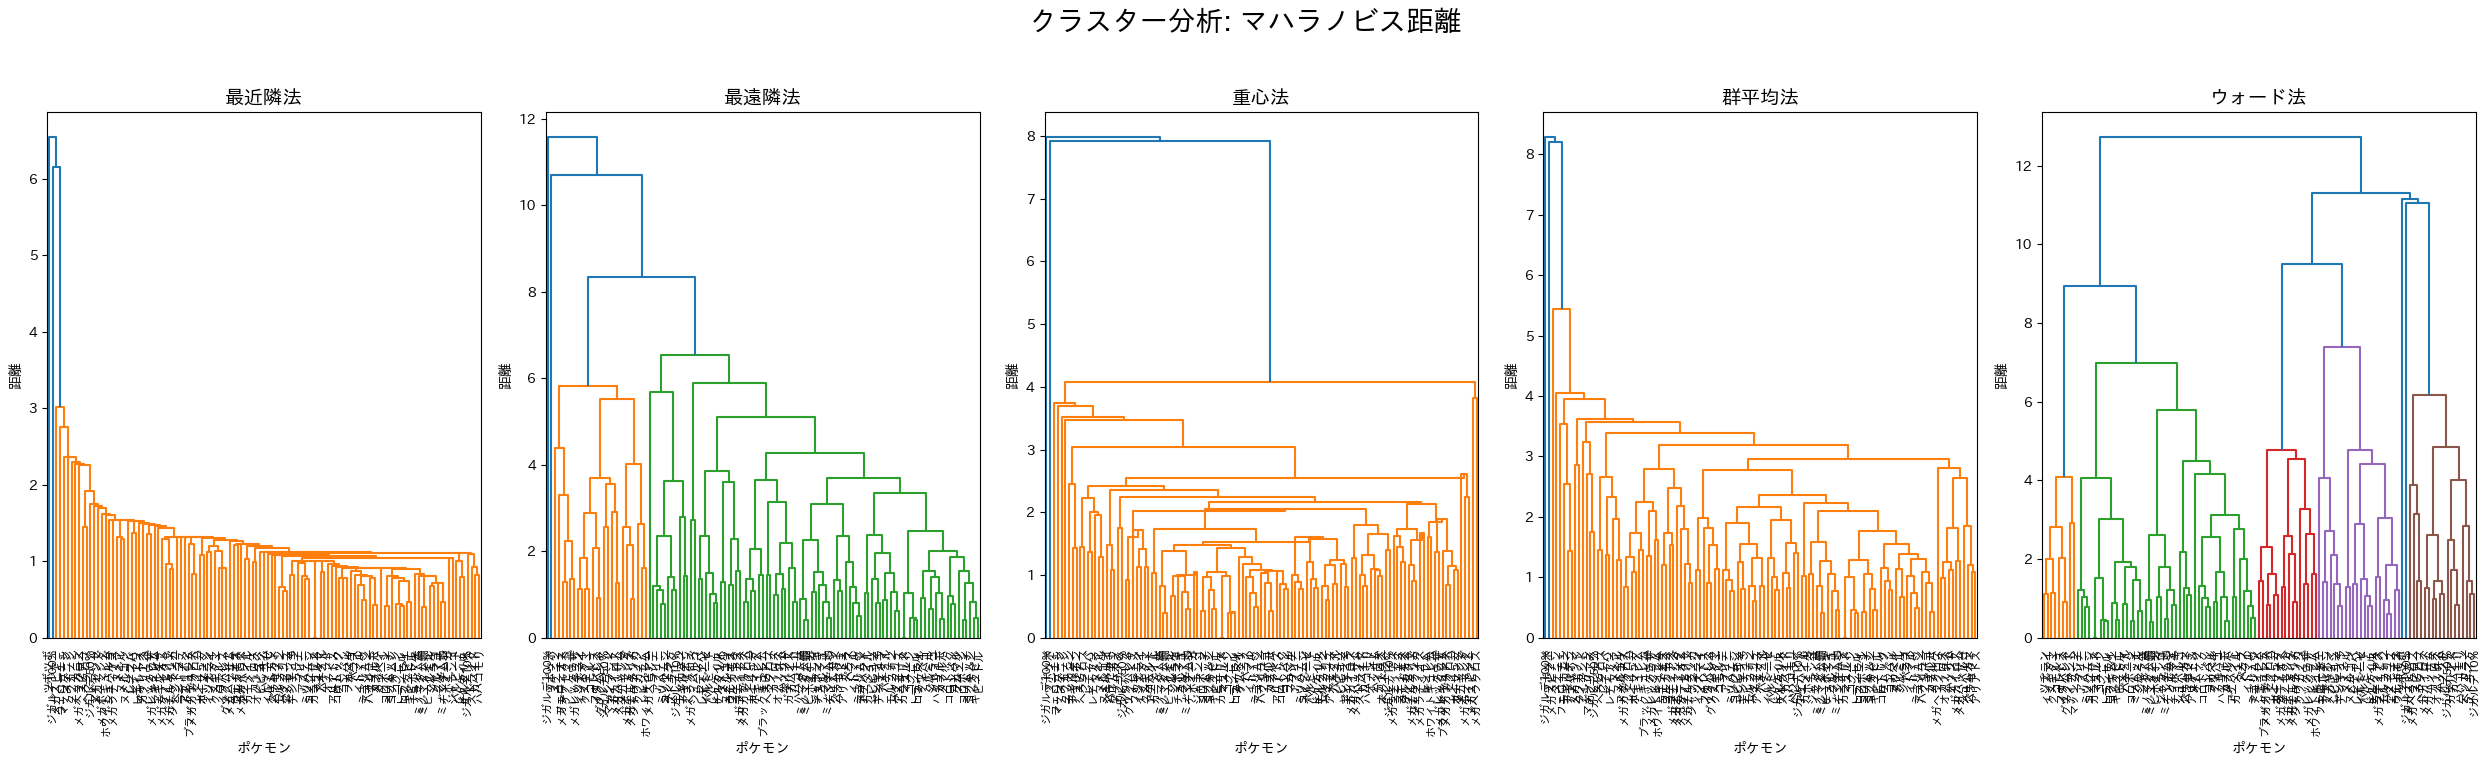

In [ ]:
#24章クラスター分析
#種族値を用いて虫タイプとドラゴンタイプをクラスターに分ける
#データ加工
target_types_ca = ['むし', 'ドラゴン']
df_cluster = df[df['タイプ1'].isin(target_types_ca)].copy().reset_index(drop=True)
feature_cols_ca = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df_cluster[feature_cols_ca]
labels_ca = df_cluster['名前'].tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cov = np.cov(X_scaled.T)
inv_cov = np.linalg.inv(cov)
#分析
methods = ['single', 'complete', 'centroid', 'average', 'ward']
method_names = {
    'single': '最近隣法', 'complete': '最遠隣法', 'centroid': '重心法',
    'average': '群平均法', 'ward': 'ウォード法'
}

metrics = ['euclidean', 'cityblock', 'mahalanobis']
metric_names = {
    'euclidean': 'ユークリッド距離', 'cityblock': 'マンハッタン距離', 'mahalanobis': 'マハラノビス距離'
}
def perform_clustering_analysis(metric_key, X_data, labels, inv_cov_mat=None):
    fig, axes = plt.subplots(1, 5, figsize=(25, 8))
    fig.suptitle(f'クラスター分析: {metric_names[metric_key]}', fontsize=20)
    if metric_key == 'mahalanobis':
        d_vec = pdist(X_data, metric=metric_key, VI=inv_cov_mat)
    else:
        d_vec = pdist(X_data, metric=metric_key)

    for i, method in enumerate(methods):
        ax = axes[i]
        try:
          Z = linkage(d_vec, method=method)
          dendrogram(
                Z,
                ax=ax,
                labels=labels,
                leaf_rotation=90,
                leaf_font_size=8,
                orientation='top'
          )
          ax.set_title(method_names[method], fontsize=14)
          ax.set_xlabel('ポケモン')
          ax.set_ylabel('距離')

        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
            ax.set_title(method_names[method])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
perform_clustering_analysis('euclidean', X_scaled, labels_ca)
perform_clustering_analysis('cityblock', X_scaled, labels_ca)
perform_clustering_analysis('mahalanobis', X_scaled, labels_ca, inv_cov)

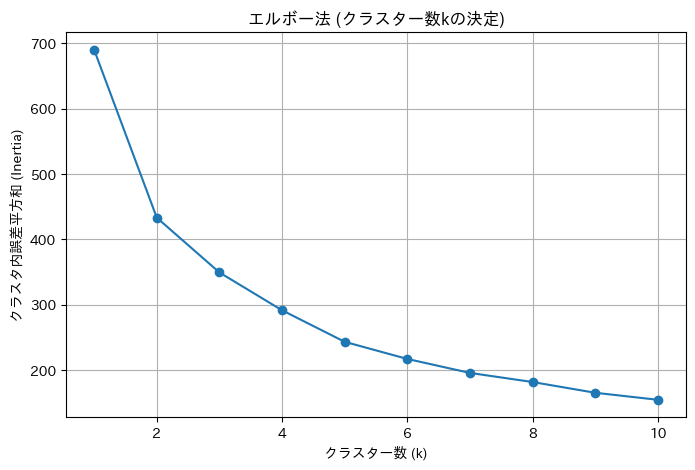

【クロス集計: タイプ vs クラスター】
Cluster   0   1
タイプ1           
むし       49  29
ドラゴン     11  26


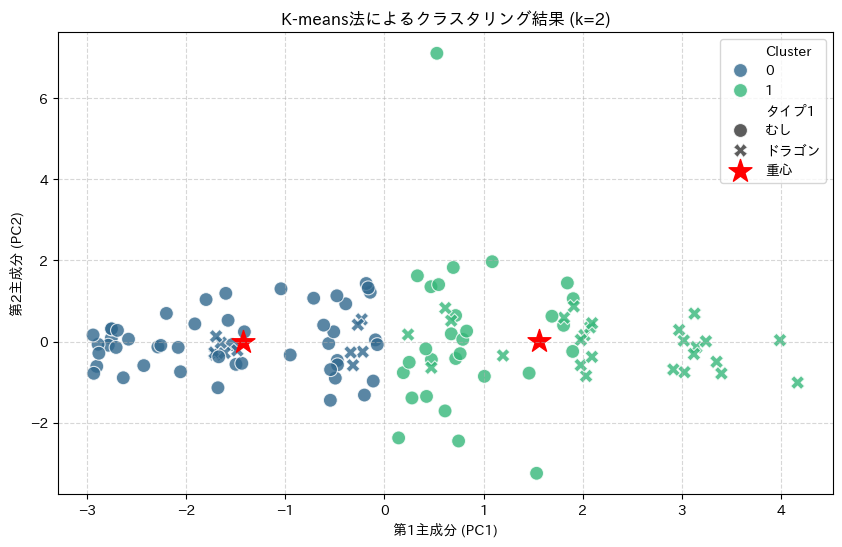

In [ ]:
#K-means法
#データ加工
target_types_km = ['むし', 'ドラゴン']
df_kmeans = df[df['タイプ1'].isin(target_types_km)].copy()
feature_cols_km = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df_kmeans[feature_cols_km]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#エルボー法
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('エルボー法 (クラスター数kの決定)')
plt.xlabel('クラスター数 (k)')
plt.ylabel('クラスタ内誤差平方和 (Inertia)')
plt.grid(True)
plt.show()
#k=2でK-means法
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_kmeans['Cluster'] = clusters
print("【クロス集計: タイプ vs クラスター】")
print(pd.crosstab(df_kmeans['タイプ1'], df_kmeans['Cluster']))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_kmeans['PC1'] = X_pca[:, 0]
df_kmeans['PC2'] = X_pca[:, 1]
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster', style='タイプ1',
    data=df_kmeans,
    palette='viridis',
    s=100, alpha=0.8
)
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=300, color='red', label='重心')

plt.title(f'K-means法によるクラスタリング結果 (k={k})')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

【因子分析の結果】
        第1因子      第2因子       独自性       共通性
HP  0.227222  0.442040  0.752967  0.247033
攻撃  0.417762  0.435312  0.635979  0.364021
防御  0.976548  0.069063  0.041777  0.958223
特攻  0.168064  0.798644  0.333921  0.666079
特防  0.499487  0.473645  0.526155  0.473845
素早 -0.055762  0.598206  0.639026  0.360974


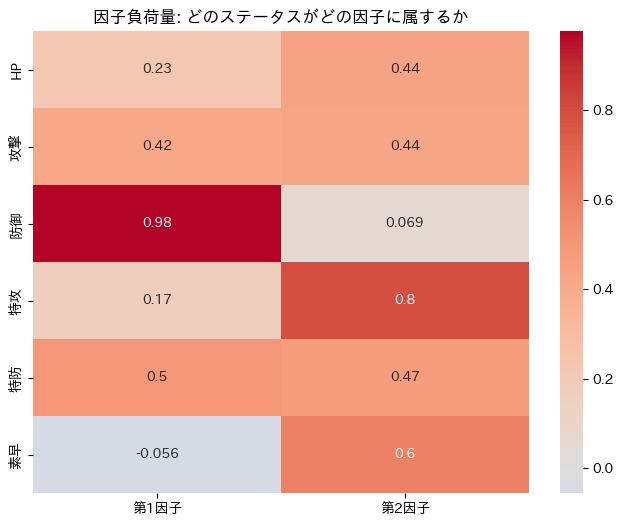

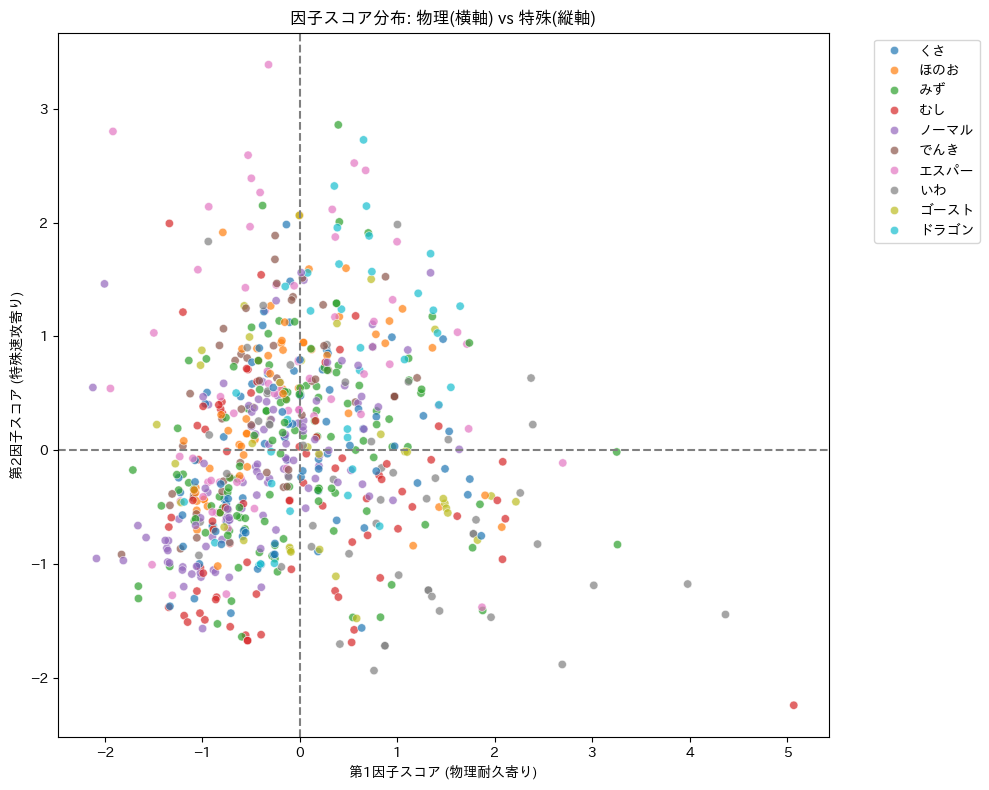

In [ ]:
#25章因子分析、グラフィカルモデル
#データ加工
feature_cols_fa = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df[feature_cols_fa]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
fa = FactorAnalysis(n_components=2, rotation='varimax', random_state=42)
X_fa = fa.fit_transform(X_scaled)
#分析
loadings = fa.components_.T
df_loadings = pd.DataFrame(loadings, columns=['第1因子', '第2因子'], index=feature_cols_fa)
uniqueness = fa.noise_variance_
communality = 1 - uniqueness
df_result = pd.concat([
    df_loadings,
    pd.DataFrame({'独自性': uniqueness, '共通性': communality}, index=feature_cols_fa)
], axis=1)
print("【因子分析の結果】")
print(df_result)
#図示
plt.figure(figsize=(8, 6))
sns.heatmap(df_loadings, annot=True, cmap='coolwarm', center=0)
plt.title('因子負荷量: どのステータスがどの因子に属するか')
plt.show()
df_scores = pd.DataFrame(X_fa, columns=['Score1', 'Score2'])
df_with_scores = pd.concat([df[['名前', 'タイプ1']], df_scores], axis=1)
top_types = df['タイプ1'].value_counts().index[:10]
subset = df_with_scores[df_with_scores['タイプ1'].isin(top_types)]
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Score1', y='Score2',
    hue='タイプ1',
    data=subset,
    palette='tab10',
    alpha=0.7
)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title('因子スコア分布: 物理(横軸) vs 特殊(縦軸)')
plt.xlabel('第1因子スコア (物理耐久寄り)')
plt.ylabel('第2因子スコア (特殊速攻寄り)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

--- 因子負荷量比較表 ---


回転手法    初期解        バリマックス        プロマックス       
因子     第1因子   第2因子   第1因子   第2因子   第1因子   第2因子
HP    0.285  0.407  0.227  0.442  0.076  0.178
攻撃    0.473  0.374  0.418  0.435  0.230  0.158
防御    0.977 -0.065  0.977  0.069  0.766 -0.053
特攻    0.276  0.768  0.168  0.799 -0.057  0.342
特防    0.559  0.401  0.499  0.474  0.287  0.168
素早    0.026  0.600 -0.056  0.598 -0.188  0.272

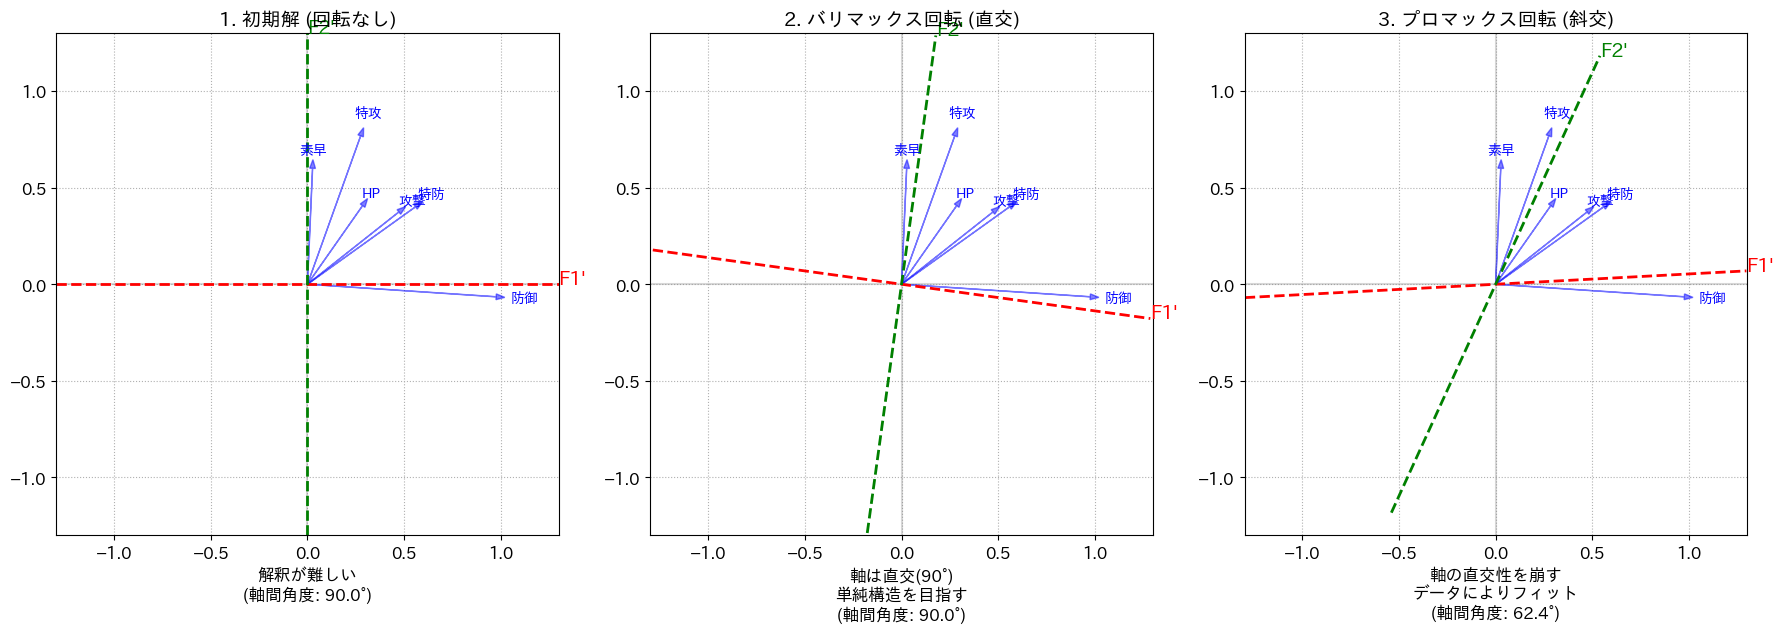

In [ ]:
#因子回転
#
#データ加工
plt.rcParams['font.size'] = 12
feature_cols_fr = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df[feature_cols_fr]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#回転
fa_init = FactorAnalysis(n_components=2, rotation=None)
fa_init.fit(X_scaled)
L_init = fa_init.components_.T
fa_vari = FactorAnalysis(n_components=2, rotation='varimax')
fa_vari.fit(X_scaled)
L_vari = fa_vari.components_.T
k = 4
L_target = np.abs(L_vari)**(k-1) * np.sign(L_vari)
T_pro, _, _, _ = np.linalg.lstsq(L_vari, L_target, rcond=None)
L_pro = np.dot(L_vari, T_pro)
columns = pd.MultiIndex.from_product(
    [['初期解', 'バリマックス', 'プロマックス'], ['第1因子', '第2因子']],
    names=['回転手法', '因子']
)
data = np.hstack([L_init, L_vari, L_pro])
df_loadings = pd.DataFrame(data, index=feature_cols_fr, columns=columns)
print("--- 因子負荷量比較表 ---")
display(df_loadings.round(3))
#図示
k = 4
L_target = np.abs(L_vari)**(k-1) * np.sign(L_vari)
T_pro, _, _, _ = np.linalg.lstsq(L_vari, L_target, rcond=None)
L_pro = np.dot(L_vari, T_pro)
def get_axis_vectors(L_base, L_rotated):
    M, _, _, _ = np.linalg.lstsq(L_base, L_rotated, rcond=None)
    def get_perp(v): return np.array([v[1], -v[0]])
    vec1 = get_perp(M[:, 1])
    vec2 = get_perp(M[:, 0])
    vec1 = vec1 / np.linalg.norm(vec1)
    vec2 = vec2 / np.linalg.norm(vec2)
    idx1 = np.argmax(np.abs(L_rotated[:, 0]))
    if np.dot(vec1, L_base[idx1]) * np.sign(L_rotated[idx1, 0]) < 0:
        vec1 = -vec1
    idx2 = np.argmax(np.abs(L_rotated[:, 1]))
    if np.dot(vec2, L_base[idx2]) * np.sign(L_rotated[idx2, 1]) < 0:
        vec2 = -vec2
    return vec1, vec2
v1_init, v2_init = np.array([1, 0]), np.array([0, 1])
v1_vari, v2_vari = get_axis_vectors(L_init, L_vari)
v1_pro, v2_pro   = get_axis_vectors(L_init, L_pro)
def plot_axes(ax, vec1, vec2, title, subtitle):
    ax.axhline(0, color='gray', alpha=0.3)
    ax.axvline(0, color='gray', alpha=0.3)
    for i, col in enumerate(feature_cols_fr):
        x, y = L_init[i, 0], L_init[i, 1]
        ax.arrow(0, 0, x, y, color='blue', alpha=0.5, head_width=0.03, zorder=2)
        ax.text(x*1.15, y*1.15, col, color='blue', ha='center', va='center', fontsize=10)
    scale = 1.3
    ax.plot([-vec1[0]*scale, vec1[0]*scale], [-vec1[1]*scale, vec1[1]*scale],
            color='red', linestyle='--', linewidth=2, label="第1因子軸")
    ax.text(vec1[0]*scale, vec1[1]*scale, "F1'", color='red', fontsize=14, fontweight='bold')
    ax.plot([-vec2[0]*scale, vec2[0]*scale], [-vec2[1]*scale, vec2[1]*scale],
            color='green', linestyle='--', linewidth=2, label="第2因子軸")
    ax.text(vec2[0]*scale, vec2[1]*scale, "F2'", color='green', fontsize=14, fontweight='bold')
    cos_angle = np.dot(vec1, vec2)
    angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(subtitle + f"\n(軸間角度: {angle:.1f}°)")
    ax.grid(True, linestyle=':')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_axes(axes[0], v1_init, v2_init, "1. 初期解 (回転なし)", "解釈が難しい")
plot_axes(axes[1], v1_vari, v2_vari, "2. バリマックス回転 (直交)", "軸は直交(90°)\n単純構造を目指す")
plot_axes(axes[2], v1_pro, v2_pro,   "3. プロマックス回転 (斜交)", "軸の直交性を崩す\nデータによりフィット")
plt.tight_layout()
plt.show()

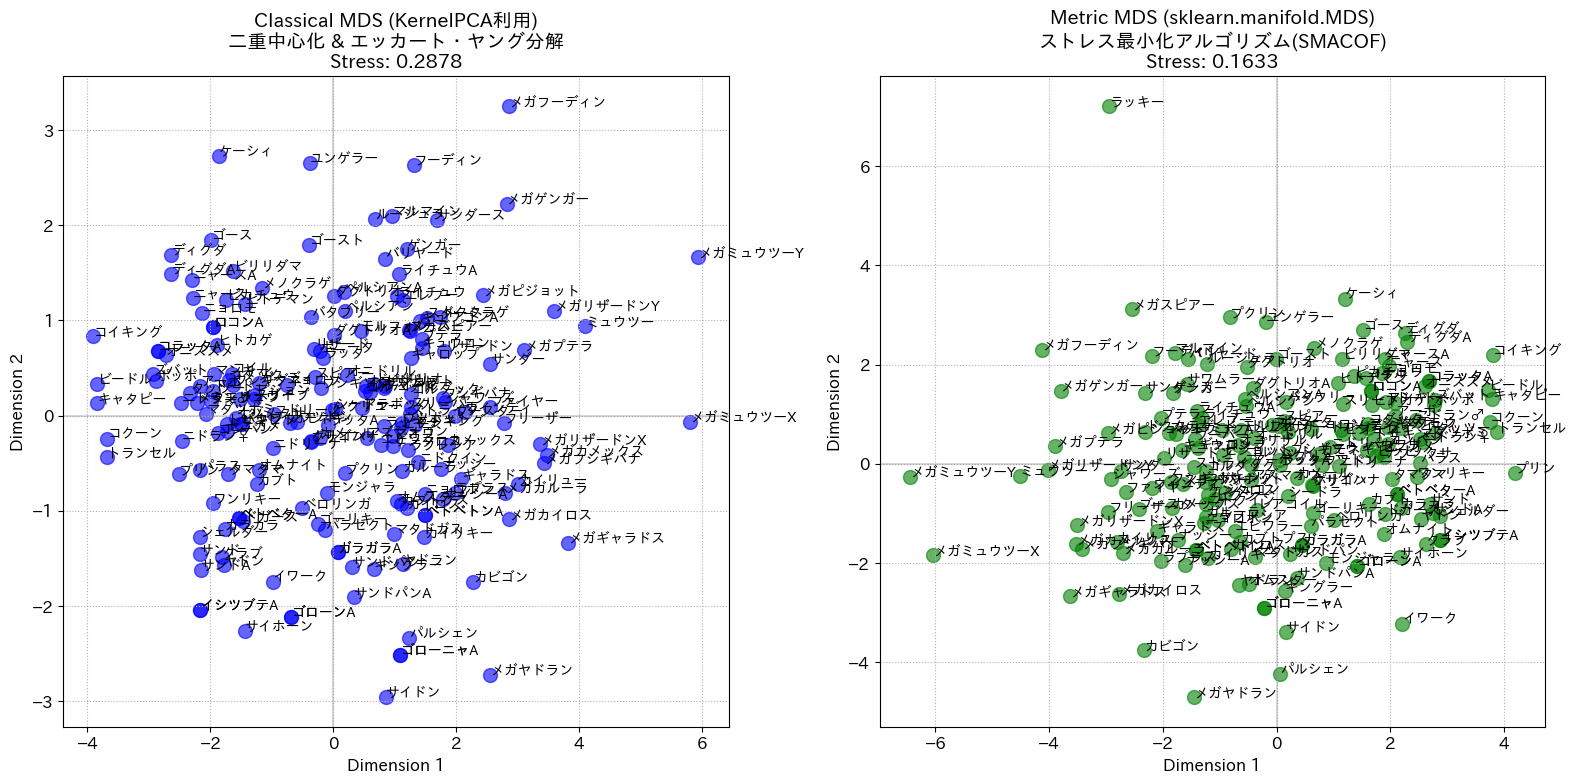

--- Classical MDS Stress: 0.2878 ---
--- Metric MDS Stress:    0.1633 ---


In [ ]:
#26章その他の多変量解析手法
#データ加工
ln = 183 #関東地方のみ
target_pokemon = df.iloc[:ln].copy()
names = target_pokemon['名前'].values
feature_cols_mds = ['HP', '攻撃', '防御', '特攻', '特防', '素早', '合計種族値']
X = target_pokemon[feature_cols_mds].values
caler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#計算
D = pairwise_distances(X_scaled, metric='euclidean')
K = -0.5 * (D ** 2)
kpca = KernelPCA(n_components=2, kernel='precomputed')
coords_classical = kpca.fit_transform(K)
dist_classical = pairwise_distances(coords_classical, metric='euclidean')
numerator = np.sum((D - dist_classical)**2)
denominator = np.sum(D**2)
stress_classical = np.sqrt(numerator / denominator)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_metric = mds.fit_transform(D)
dist_metric = pairwise_distances(coords_metric, metric='euclidean')
numerator_m = np.sum((D - dist_metric)**2)
denominator_m = np.sum(D**2)
stress_metric = np.sqrt(numerator_m / denominator_m)
#図示
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.scatter(coords_classical[:, 0], coords_classical[:, 1], c='blue', alpha=0.6, s=100)
for i, name in enumerate(names):
    plt.text(coords_classical[i, 0], coords_classical[i, 1], name, fontsize=10)
plt.title(f"Classical MDS (KernelPCA利用)\n二重中心化 & エッカート・ヤング分解\nStress: {stress_classical:.4f}", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle=':')
plt.axhline(0, color='gray', alpha=0.3)
plt.axvline(0, color='gray', alpha=0.3)
plt.subplot(1, 2, 2)
plt.scatter(coords_metric[:, 0], coords_metric[:, 1], c='green', alpha=0.6, s=100)
for i, name in enumerate(names):
    plt.text(coords_metric[i, 0], coords_metric[i, 1], name, fontsize=10)
plt.title(f"Metric MDS (sklearn.manifold.MDS)\nストレス最小化アルゴリズム(SMACOF)\nStress: {stress_metric:.4f}", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle=':')
plt.axhline(0, color='gray', alpha=0.3)
plt.axvline(0, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"--- Classical MDS Stress: {stress_classical:.4f} ---")
print(f"--- Metric MDS Stress:    {stress_metric:.4f} ---")

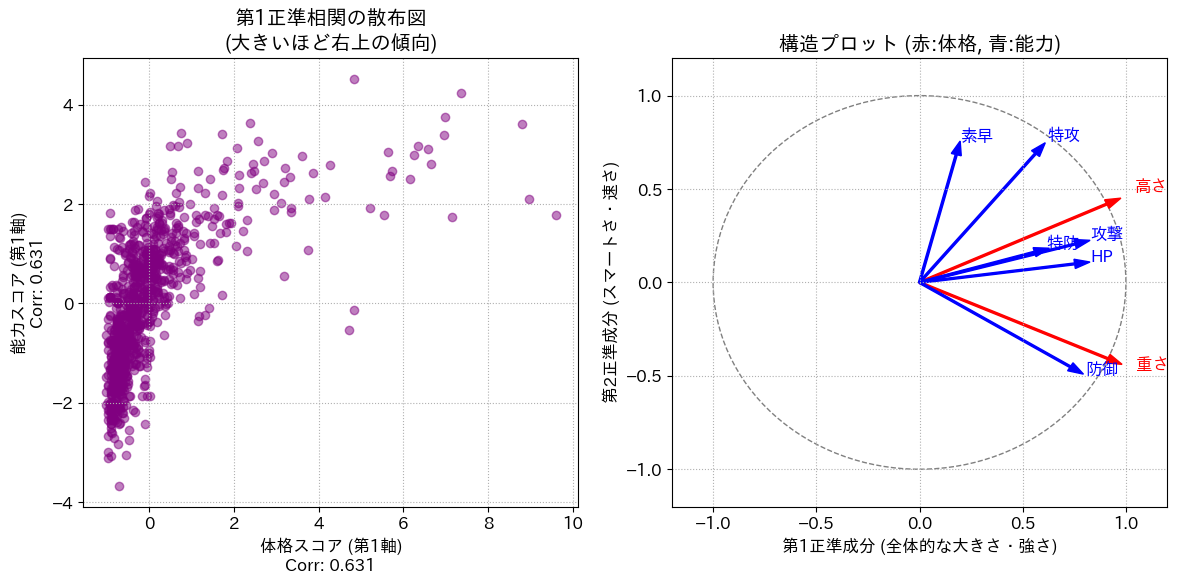

第1正準相関係数: 0.6312
第2正準相関係数: 0.2440


In [ ]:
#正準相関分析
#身長体重と種族値に関係があるか
#データ加工
group_x_cols = ['高さ', '重さ']
group_y_cols = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X = df[group_x_cols]
Y = df[group_y_cols]
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(X)
Y_sc = scaler_y.fit_transform(Y)
#計算
cca = CCA(n_components=2)
cca.fit(X_sc, Y_sc)
X_c, Y_c = cca.transform(X_sc, Y_sc)
corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(2)]

loadings_x = np.array([[np.corrcoef(X_sc[:, j], X_c[:, i])[0, 1] for i in range(cca.n_components)] for j in range(X.shape[1])])
loadings_y = np.array([[np.corrcoef(Y_sc[:, j], Y_c[:, i])[0, 1] for i in range(cca.n_components)] for j in range(Y.shape[1])])

#図示
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_c[:, 0], Y_c[:, 0], alpha=0.5, c='purple')
plt.xlabel(f'体格スコア (第1軸)\nCorr: {corrs[0]:.3f}')
plt.ylabel(f'能力スコア (第1軸)\nCorr: {corrs[0]:.3f}')
plt.title('第1正準相関の散布図\n(大きいほど右上の傾向)')
plt.grid(True, linestyle=':')
plt.subplot(1, 2, 2)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)
for i, var in enumerate(group_x_cols):
    plt.arrow(0, 0, loadings_x[i, 0], loadings_x[i, 1], color='red', width=0.01, head_width=0.05)
    plt.text(loadings_x[i, 0]*1.15, loadings_x[i, 1]*1.15, var, color='red', fontweight='bold')

for i, var in enumerate(group_y_cols):
    plt.arrow(0, 0, loadings_y[i, 0], loadings_y[i, 1], color='blue', width=0.01, head_width=0.05)
    plt.text(loadings_y[i, 0]*1.1, loadings_y[i, 1]*1.1, var, color='blue')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel('第1正準成分 (全体的な大きさ・強さ)')
plt.ylabel('第2正準成分 (スマートさ・速さ)')
plt.title('構造プロット (赤:体格, 青:能力)')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
print(f"第1正準相関係数: {corrs[0]:.4f}")
print(f"第2正準相関係数: {corrs[1]:.4f}")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   №             920 non-null    object 
 1   名前            920 non-null    object 
 2   英語名           920 non-null    object 
 3   HP            920 non-null    int64  
 4   攻撃            920 non-null    int64  
 5   防御            920 non-null    int64  
 6   特攻            920 non-null    int64  
 7   特防            920 non-null    int64  
 8   素早            920 non-null    int64  
 9   合計種族値         920 non-null    int64  
 10  タイプ1          920 non-null    object 
 11  タイプ2          495 non-null    object 
 12  特性1特性2(隠し特性)  920 non-null    object 
 13  高さ            920 non-null    float64
 14  重さ            920 non-null    float64
 15  捕獲率           920 non-null    int64  
 16  性別            920 non-null    object 
 17  経験値           920 non-null    int64  
 18  初期なつき度        920 non-null    

In [ ]:
#28章分割表
#オッズ
#データ加工
dfo=df.copy()
dfo['Is_Strong'] = dfo['合計種族値'] >= 570
dfo['Is_Genderless'] = dfo['性別'] == '不明'
cross_table = pd.crosstab(dfo['Is_Strong'], dfo['Is_Genderless'])
n11 = cross_table.loc[True, True]   # a (Strong & Unknown)
n10 = cross_table.loc[True, False]  # b (Strong & Known)
n01 = cross_table.loc[False, True]  # c (Weak & Unknown)
n00 = cross_table.loc[False, False] # d (Weak & Known)
#計算
odds_ratio = (n11 * n00) / (n10 * n01)
log_odds_ratio = np.log(odds_ratio)
risk_strong = n11 / (n11 + n10)
risk_weak = n01 / (n01 + n00)
relative_risk = risk_strong / risk_weak
print(cross_table)
print(f"オッズ比: {odds_ratio:.4f}")
print(f"対数オッズ比: {log_odds_ratio:.4f}")
print(f"相対リスク: {relative_risk:.4f}")

Is_Genderless  False  True 
Is_Strong                  
False            736     41
True              54     89
オッズ比: 29.5863
対数オッズ比: 3.3873
相対リスク: 11.7948


In [ ]:
#適合度カイ二乗検定
#データ加工
observed_counts = df['タイプ1'].value_counts()
expected_counts = [observed_counts.sum() / len(observed_counts)] * len(observed_counts)
#検定
chi2_stat, p_val_chi2 = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f"--- 適合度カイ二乗検定 (Type 1 Distribution) ---")
print(f"カイ二乗統計量: {chi2_stat:.4f}")
print(f"P値: {p_val_chi2:.4e}")
if p_val_chi2 < 0.05:
    print("判定: 有意 (タイプ分布は偏っている)")

--- 適合度カイ二乗検定 (Type 1 Distribution) ---
カイ二乗統計量: 388.2326
P値: 2.5913e-71
判定: 有意 (タイプ分布は偏っている)


In [ ]:
#フィッシャーの正確検定
#データ加工
dff=df.copy()
dff['Is_Strong'] = dff['合計種族値'] >= 570
dff['Is_Genderless'] = dff['性別'] == '不明'
table = pd.crosstab(dff['Is_Strong'], dff['Is_Genderless'])
#検定
odds_ratio, p_val_fisher = stats.fisher_exact(table, alternative='two-sided')
print(f"\n--- フィッシャーの正確検定 (Strong vs Genderless) ---")
print("分割表:")
print(table)
print(f"オッズ比: {odds_ratio:.4f}")
print(f"P値: {p_val_fisher:.4e}")
if p_val_fisher < 0.05:
    print("判定: 有意 (強いポケモンと性別不明には関連がある)")


--- フィッシャーの正確検定 (Strong vs Genderless) ---
分割表:
Is_Genderless  False  True 
Is_Strong                  
False            736     41
True              54     89
オッズ比: 29.5863
P値: 1.6311e-53
判定: 有意 (強いポケモンと性別不明には関連がある)


In [ ]:
#不完全データの統計処理
#代入法
#データ加工と意図的な欠損
cols_mv = ['HP', '攻撃', '防御', '特攻', '特防', '素早']
X_complete = df[cols_mv].copy()
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.05
X_missing = X_complete.copy()
X_missing.loc[mask, '攻撃'] = np.nan
#欠損値埋め
#平均値代入法
X_mean = X_missing.copy()
X_mean['攻撃'] = X_mean['攻撃'].fillna(X_mean['攻撃'].mean())
#回帰代入法（線形回帰）
X_reg = X_missing.copy()
test_idx = X_reg['攻撃'].isnull()
train_idx = ~test_idx
predictors = ['HP', '防御', '特攻', '特防', '素早']
model = LinearRegression()
model.fit(X_reg.loc[train_idx, predictors], X_reg.loc[train_idx, '攻撃'])
X_reg.loc[test_idx, '攻撃'] = model.predict(X_reg.loc[test_idx, predictors])
#hotdeck法
X_hotdeck = X_missing.copy()
knn = KNeighborsRegressor(n_neighbors=1) # 1人のドナーを見つける
knn.fit(X_hotdeck.loc[train_idx, predictors], X_hotdeck.loc[train_idx, '攻撃'])
X_hotdeck.loc[test_idx, '攻撃'] = knn.predict(X_hotdeck.loc[test_idx, predictors])
#多重代入法
X_mice = X_missing.copy()
imputer = IterativeImputer(random_state=42)
X_mice_imputed = imputer.fit_transform(X_mice)
X_mice = pd.DataFrame(X_mice_imputed, columns=cols_mv)
#結果
results = pd.DataFrame({
    'Original': [X_complete['攻撃'].mean(), X_complete['攻撃'].std()],
    'Mean Imp': [X_mean['攻撃'].mean(), X_mean['攻撃'].std()],
    'Reg Imp': [X_reg['攻撃'].mean(), X_reg['攻撃'].std()],
    'Hot Deck': [X_hotdeck['攻撃'].mean(), X_hotdeck['攻撃'].std()],
    'MICE': [X_mice['攻撃'].mean(), X_mice['攻撃'].std()]
}, index=['Mean', 'Std'])
print(results.round(2))

      Original  Mean Imp  Reg Imp  Hot Deck   MICE
Mean     80.07     80.05    79.67     79.71  79.67
Std      32.54     31.72    32.10     32.73  32.10


/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.1

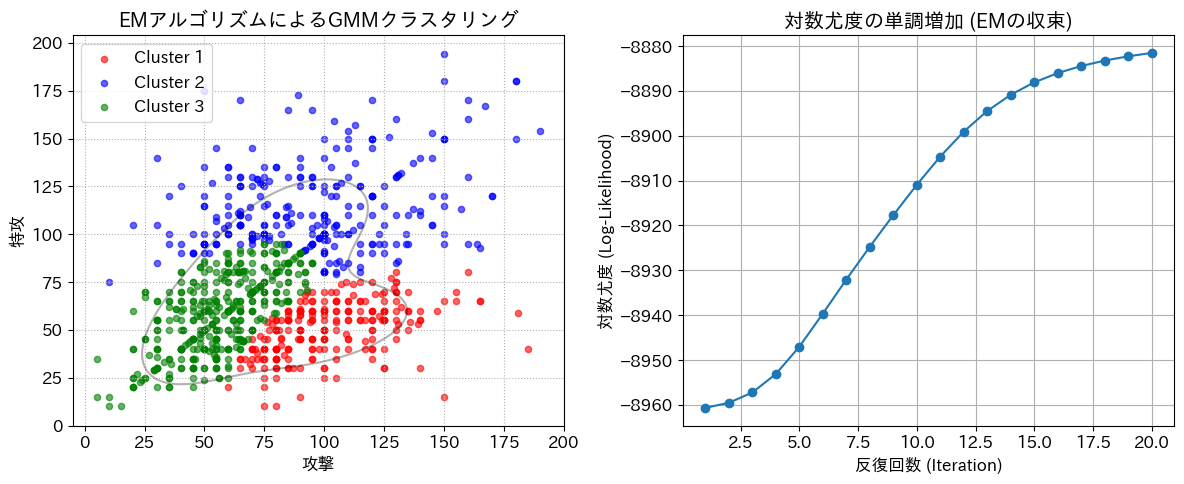

--- 各クラスターの平均ベクトル ---


,攻撃,特攻
Cluster 1,95.3,51.1
Cluster 2,91.6,106.8
Cluster 3,59.8,60.8


In [ ]:
#EMアルゴリズム
#データ加工
features_em = ['攻撃', '特攻']
X = df[features_em].values
#アルゴリズム
k = 3
gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
gmm.fit(X)
labels = gmm.predict(X)
#可視化
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for i in range(k):
    subset = X[labels == i]
    plt.scatter(subset[:, 0], subset[:, 1], s=20, alpha=0.6, label=f'Cluster {i+1}', color=colors[i])
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = -gmm.score_samples(np.c_[xx.ravel(), yy.ravel()]) # 対数尤度を計算
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=1000.0), levels=10, colors='k', alpha=0.3)
plt.xlabel('攻撃')
plt.ylabel('特攻')
plt.title('EMアルゴリズムによるGMMクラスタリング')
plt.legend()
plt.grid(True, linestyle=':')
#対数尤度の推移
plt.subplot(1, 2, 2)
log_likelihoods = []
max_iters = range(1, 21)
for i in max_iters:
    gmm_step = GaussianMixture(n_components=k, random_state=42, max_iter=i, n_init=1, init_params='random', tol=1e-9)
    gmm_step.fit(X)
    log_likelihoods.append(gmm_step.score(X) * len(X))
plt.plot(max_iters, log_likelihoods, marker='o')
plt.xlabel('反復回数 (Iteration)')
plt.ylabel('対数尤度 (Log-Likelihood)')
plt.title('対数尤度の単調増加 (EMの収束)')
plt.grid(True)
plt.tight_layout()
plt.show()
#結果
print("--- 各クラスターの平均ベクトル ---")
df_means = pd.DataFrame(gmm.means_, columns=['攻撃', '特攻'], index=[f'Cluster {i+1}' for i in range(k)])
display(df_means.round(1))